# 📐 Math for ML — The Intuition Behind the Models

> **What you'll learn:** vectors and similarity, matrices as geometric transformations, rank and solving linear systems, eigenvectors, SVD and PCA, derivatives and the chain rule, gradients and gradient descent, and the information theory behind classification losses — every idea with code and a picture, no walls of equations.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Interview-level |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [NumPy](01_NumPy.ipynb) (arrays, broadcasting, `@`) |
| **Tested with** | Python 3.12 · numpy 2.5 · matplotlib 3.11 · scikit-learn 1.9 · sympy 1.14 · scipy 1.18 |
| **Interview relevance** | ⭐⭐⭐ High — cosine similarity, PCA steps, SVD vs eigendecomposition, chain rule → backprop, gradient checking, convexity, cross-entropy and KL divergence |

## 🤔 What Is Math for ML?

Machine learning is mostly **three ideas** wearing different clothes:

| Idea | Everyday analogy | Where it shows up |
|---|---|---|
| **Linear algebra** — vectors and matrices | a GPS coordinate is a vector; a map projection is a matrix | data tables, embeddings, neural-network layers, PCA |
| **Calculus** — derivatives and gradients | the slope of a hill under your feet | training: "which way should I nudge the weights?" |
| **Information theory** — entropy and cross-entropy | how surprised you are by the weather forecast | classification losses, KL terms in VAEs and RLHF |

You don't need to prove theorems. You need to **picture** what an operation does, **compute** it in NumPy, and **explain** it in plain words. That is exactly what interviewers test.

Two words we'll use constantly:
- A **vector** is an ordered list of numbers — an arrow from the origin, or a point. `[height, weight]` is a 2-D vector.
- A **matrix** is a grid of numbers — a table of vectors, or a machine that turns one vector into another.

## 🎯 Why It Matters

- **Embeddings and search:** semantic search, recommendations and RAG rank items by **cosine similarity** between vectors.
- **Every neural network layer** is a matrix multiply plus a non-linearity; shape errors are the #1 bug.
- **Training = calculus:** backpropagation is the **chain rule** applied many times, and optimizers follow **gradients**.
- **Dimensionality reduction:** **PCA/SVD** compress data, remove noise, speed up models and power low-rank tricks like **LoRA**.
- **Losses:** cross-entropy and KL divergence are the standard losses for classification, language models and distillation.
- **In interviews** you'll be asked to *explain* PCA step by step, *derive* a gradient, *implement* cosine similarity or softmax cross-entropy, and *debug* "the loss is NaN" or "gradients don't match".

## ✅ By the End You Can

- [ ] Compute norms, dot products, cosine similarity and projections, and explain what each means geometrically
- [ ] Read a matrix as a transformation, predict matrix-multiplication shapes, and explain rank and why we `solve` instead of inverting
- [ ] Explain eigenvectors, SVD and PCA, and implement PCA from scratch that matches scikit-learn
- [ ] Take derivatives by hand, with sympy and numerically; apply the chain rule; check gradients numerically
- [ ] Run gradient descent and explain learning-rate effects, convexity, Jacobians and Hessians
- [ ] Compute entropy, cross-entropy and KL divergence and connect them to classification losses

## 📋 Table of Contents

1. [Vectors, Norms, and the Dot Product](#1.-Vectors,-Norms,-and-the-Dot-Product-🟢)
2. [Cosine Similarity and Projection](#2.-Cosine-Similarity-and-Projection-🟢)
3. [Matrices as Transformations](#3.-Matrices-as-Transformations-🟢)
4. [Matrix Multiplication and Shapes](#4.-Matrix-Multiplication-and-Shapes-🟡)
5. [Rank and Linear Independence](#5.-Rank-and-Linear-Independence-🟡)
6. [Inverses, and Why We Solve Instead](#6.-Inverses,-and-Why-We-Solve-Instead-🟡)
7. [Eigenvalues and Eigenvectors](#7.-Eigenvalues-and-Eigenvectors-🟡)
8. [SVD and PCA](#8.-SVD-and-PCA-🔴)
9. [Derivatives and Partial Derivatives](#9.-Derivatives-and-Partial-Derivatives-🟢)
10. [The Chain Rule](#10.-The-Chain-Rule-🟡)
11. [Gradients and Numerical Gradient Checking](#11.-Gradients-and-Numerical-Gradient-Checking-🟡)
12. [Gradient Descent and Learning Rates](#12.-Gradient-Descent-and-Learning-Rates-🟡)
13. [Jacobians, Hessians, and Convexity](#13.-Jacobians,-Hessians,-and-Convexity-🔴)
14. [Information Theory for ML](#14.-Information-Theory-for-ML-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Image-Compression-with-Truncated-SVD) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "numpy>=2.0" "matplotlib>=3.8" "scikit-learn>=1.5" "sympy>=1.12" "scipy>=1.11"

import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn
import sympy as sp

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | matplotlib {matplotlib.__version__} | "
      f"scikit-learn {sklearn.__version__} | SymPy {sp.__version__} | SciPy {scipy.__version__}")

rng = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)
OUTPUT_DIR = Path("_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-5, atol=1e-8):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    assert np.allclose(got_arr, exp_arr, rtol=rtol, atol=atol), f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")


def draw_arrows(ax, vectors, colors, labels, lim=3):
    """Draw 2-D vectors as arrows from the origin."""
    for v, c, lab in zip(vectors, colors, labels):
        ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
        ax.text(v[0] * 1.08, v[1] * 1.08, lab, color=c, fontsize=11)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color="#BBBBBB", lw=0.8)
    ax.axvline(0, color="#BBBBBB", lw=0.8)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

Python 3.12.11 | NumPy 2.5.3 | matplotlib 3.11.2 | scikit-learn 1.9.1 | SymPy 1.14.0 | SciPy 1.18.1


## 1. Vectors, Norms, and the Dot Product 🟢

A vector has a **direction** and a **length**.

- **Norm** = length. The usual one is the **L2 (Euclidean) norm** $\lVert v \rVert_2 = \sqrt{v_1^2 + v_2^2 + \dots}$ — Pythagoras.
  The **L1 norm** $\lVert v \rVert_1 = |v_1| + |v_2| + \dots$ is "taxicab" distance (walk along streets, no diagonals).
- **Dot product** $a \cdot b = a_1 b_1 + a_2 b_2 + \dots$ — multiply matching entries and add. Geometrically, $a \cdot b = \lVert a \rVert \lVert b \rVert \cos\theta$:
  positive when the arrows point the same general way, **zero when perpendicular**, negative when opposite.

```
  a · b > 0         a · b = 0          a · b < 0
   ↗ ↗               ↑ →                ↗ ↙
 (same-ish)       (perpendicular)     (opposite-ish)
```

In [2]:
a = np.array([3.0, 4.0])
b = np.array([4.0, -3.0])
c = np.array([-3.0, -1.0])

print("L2 norm of a:", np.linalg.norm(a), "= sqrt(3² + 4²)")
print("L1 norm of a:", np.linalg.norm(a, ord=1), "= |3| + |4|")
print("L∞ norm of a:", np.linalg.norm(a, ord=np.inf), "= largest |entry|")
print("unit vector a/‖a‖:", a / np.linalg.norm(a), "→ length", np.linalg.norm(a / np.linalg.norm(a)))
print()
print("a · b =", a @ b, "(perpendicular)")
print("a · c =", a @ c, "(pointing away)")
print("a · a =", a @ a, "= ‖a‖² ")

L2 norm of a: 5.0 = sqrt(3² + 4²)
L1 norm of a: 7.0 = |3| + |4|
L∞ norm of a: 4.0 = largest |entry|
unit vector a/‖a‖: [0.6 0.8] → length 1.0

a · b = 0.0 (perpendicular)
a · c = -13.0 (pointing away)
a · a = 25.0 = ‖a‖² 


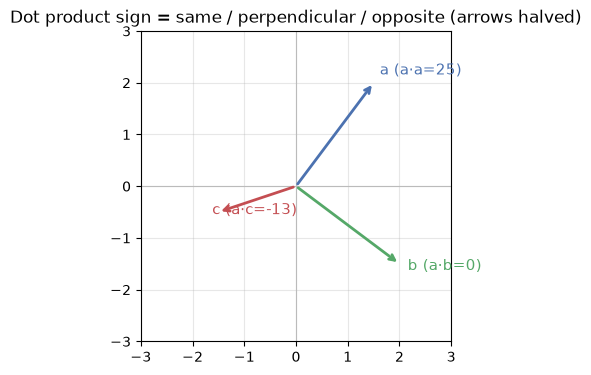

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
draw_arrows(ax, [a / 2, b / 2, c / 2], ["#4C72B0", "#55A868", "#C44E52"],
            [f"a (a·a={a @ a:.0f})", f"b (a·b={a @ b:.0f})", f"c (a·c={a @ c:.0f})"])
ax.set_title("Dot product sign = same / perpendicular / opposite (arrows halved)")
plt.tight_layout()
plt.show()

**Real data:** each iris flower is a 4-D vector of measurements. Distances between vectors tell us which flowers are alike.

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data                                   # (150, 4): sepal length/width, petal length/width in cm
setosa, versicolor, virginica = X_iris[0], X_iris[50], X_iris[100]
print("feature names:", iris.feature_names)
print(f"‖setosa − versicolor‖₂ = {np.linalg.norm(setosa - versicolor):.2f} cm")
print(f"‖versicolor − virginica‖₂ = {np.linalg.norm(versicolor - virginica):.2f} cm")
print(f"‖setosa − virginica‖₂ = {np.linalg.norm(setosa - virginica):.2f} cm  → setosa is the odd one out")

feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
‖setosa − versicolor‖₂ = 4.00 cm
‖versicolor − virginica‖₂ = 1.84 cm
‖setosa − virginica‖₂ = 5.28 cm  → setosa is the odd one out


### ✍️ Your Turn

Scale `v` to a **unit vector** (length 1, same direction).

In [5]:
v = np.array([1.0, 2.0, 2.0])
v_unit = None  # TODO: your code here
check("unit_vector", v_unit, [1 / 3, 2 / 3, 2 / 3], hint="Divide by np.linalg.norm(v). ‖v‖ = sqrt(1 + 4 + 4) = 3.")

⏳ unit_vector: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
v = np.array([1.0, 2.0, 2.0])
v_unit = v / np.linalg.norm(v)
check("unit_vector", v_unit, [1 / 3, 2 / 3, 2 / 3])
```

Normalizing embeddings to unit length is common: afterwards the dot product *is* the cosine similarity.
</details>

> 💡 **Interview angle:** "L1 vs L2 norm?" — L2 is straight-line length and penalizes big entries heavily (squares); L1 sums absolute values. As regularizers, L2 (ridge) shrinks all weights smoothly while L1 (lasso) pushes many weights to exactly zero (sparsity).

## 2. Cosine Similarity and Projection 🟢

**Cosine similarity** compares **directions only**, ignoring length:
$\cos\theta = \dfrac{a \cdot b}{\lVert a \rVert \lVert b \rVert}$, from −1 (opposite) through 0 (unrelated) to 1 (same direction).

Why ignore length? A long document and a short document about the same topic should count as similar. Embedding search uses cosine similarity for exactly this reason.

**Projection** answers "how much of `b` points along `a`?" — the *shadow* of `b` on the line through `a`:
$\text{proj}_a(b) = \dfrac{a \cdot b}{a \cdot a}\, a$. The leftover `b − proj` is perpendicular to `a`. Least-squares regression and PCA are both projections.

In [6]:
def cosine_similarity(u, w):
    return (u @ w) / (np.linalg.norm(u) * np.linalg.norm(w))


doc_short = np.array([2.0, 1.0, 0.0])        # word counts for ["model", "training", "recipe"]
doc_long = np.array([20.0, 10.0, 0.0])       # same topic, 10× longer
doc_food = np.array([0.0, 1.0, 9.0])

print(f"cos(short, long) = {cosine_similarity(doc_short, doc_long):.3f}  | Euclidean distance = {np.linalg.norm(doc_short - doc_long):.1f}")
print(f"cos(short, food) = {cosine_similarity(doc_short, doc_food):.3f}  | Euclidean distance = {np.linalg.norm(doc_short - doc_food):.1f}")
print("→ cosine says short≈long (same topic); raw distance says short is closer to the food doc.")

cos(short, long) = 1.000  | Euclidean distance = 20.1
cos(short, food) = 0.049  | Euclidean distance = 9.2
→ cosine says short≈long (same topic); raw distance says short is closer to the food doc.


In [7]:
# Cosine similarity on real data: which flowers are most alike? (after centering each feature)
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

Xc_iris = X_iris - X_iris.mean(axis=0)
unit_rows = Xc_iris / np.linalg.norm(Xc_iris, axis=1, keepdims=True)
S_ours = unit_rows @ unit_rows.T                     # all pairwise cosines in one matrix multiply
assert np.allclose(S_ours, sk_cosine(Xc_iris))
species_mean = np.array([[S_ours[iris.target == i][:, iris.target == j].mean() for j in range(3)] for i in range(3)])
print("mean cosine similarity between species (rows/cols: setosa, versicolor, virginica):\n", species_mean)

mean cosine similarity between species (rows/cols: setosa, versicolor, virginica):
 [[ 0.965 -0.558 -0.93 ]
 [-0.558  0.429  0.514]
 [-0.93   0.514  0.903]]


projection: [2.1 0.7] | residual: [-0.6  1.8] | residual · a = 0.0


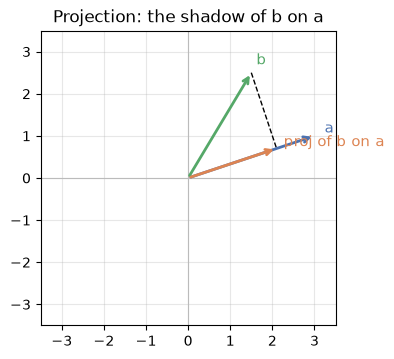

In [8]:
# Projection of b onto a, and a picture
a2 = np.array([3.0, 1.0])
b2 = np.array([1.5, 2.5])
proj = (a2 @ b2) / (a2 @ a2) * a2
residual = b2 - proj
print("projection:", proj, "| residual:", residual, "| residual · a =", round(float(residual @ a2), 12))

fig, ax = plt.subplots(figsize=(4, 4))
draw_arrows(ax, [a2, b2, proj], ["#4C72B0", "#55A868", "#DD8452"], ["a", "b", "proj of b on a"], lim=3.5)
ax.plot([b2[0], proj[0]], [b2[1], proj[1]], "k--", lw=1)
ax.set_title("Projection: the shadow of b on a")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Project `y` onto the direction `d`. Return the projection vector.

In [9]:
y = np.array([2.0, 3.0])
d = np.array([1.0, 1.0])
y_on_d = None  # TODO
check("projection", y_on_d, [2.5, 2.5], hint="(d @ y) / (d @ d) * d")

⏳ projection: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y = np.array([2.0, 3.0])
d = np.array([1.0, 1.0])
y_on_d = (d @ y) / (d @ d) * d
check("projection", y_on_d, [2.5, 2.5])
```

Sanity check: the residual `y - y_on_d = [-0.5, 0.5]` has zero dot product with `d`.
</details>

> 💡 **Interview angle:** "Cosine similarity vs Euclidean distance for embeddings?" — cosine ignores vector length, so it compares meaning/direction; on **unit-normalized** vectors they rank neighbours identically because $\lVert a-b \rVert^2 = 2 - 2\cos\theta$.

## 3. Matrices as Transformations 🟢

Multiplying a vector by a matrix **moves** it. A 2×2 matrix can stretch, squash, rotate, reflect or shear the whole plane.

**The one trick to read any matrix:** its **columns are where the basis arrows land**. Column 1 is where `[1, 0]` goes; column 2 is where `[0, 1]` goes. Every other point follows along (that's what "linear" means: grid lines stay straight and evenly spaced, and the origin stays put).

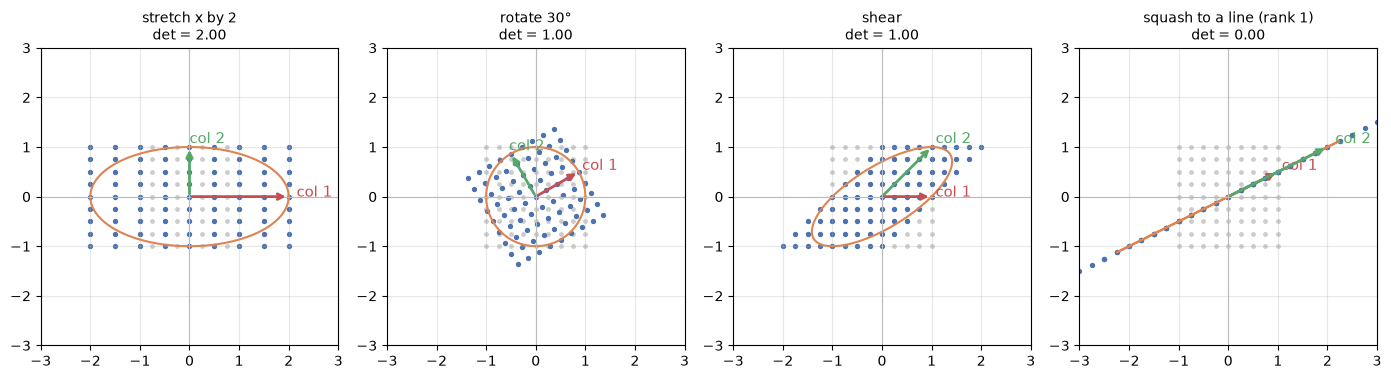

In [10]:
theta = np.pi / 6
transforms = {
    "stretch x by 2": np.array([[2.0, 0.0], [0.0, 1.0]]),
    "rotate 30°": np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]),
    "shear": np.array([[1.0, 1.0], [0.0, 1.0]]),
    "squash to a line (rank 1)": np.array([[1.0, 2.0], [0.5, 1.0]]),
}

# A grid of points and a unit circle to watch
gx, gy = np.meshgrid(np.linspace(-1, 1, 9), np.linspace(-1, 1, 9))
grid_pts = np.stack([gx.ravel(), gy.ravel()])        # shape (2, 81): one column per point
circle = np.stack([np.cos(np.linspace(0, 2 * np.pi, 100)), np.sin(np.linspace(0, 2 * np.pi, 100))])

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (name, M) in zip(axes, transforms.items()):
    moved = M @ grid_pts                              # transform ALL points with one matrix multiply
    ax.scatter(grid_pts[0], grid_pts[1], s=6, color="#CCCCCC")
    ax.scatter(moved[0], moved[1], s=8, color="#4C72B0")
    ax.plot(*(M @ circle), color="#DD8452")
    draw_arrows(ax, [M[:, 0], M[:, 1]], ["#C44E52", "#55A868"], ["col 1", "col 2"], lim=3)
    ax.set_title(f"{name}\ndet = {np.linalg.det(M):.2f}", fontsize=10)
plt.tight_layout()
plt.show()

The **determinant** is the factor by which areas scale: 2 for the stretch, 1 for rotation and shear (area preserved), and **0** for the squash — the whole plane collapses onto a line, so information is lost and the transformation can't be undone.

> 💡 **Interview angle:** "What does a neural-network layer do geometrically?" — `W @ x + b` is a linear transformation (rotate/stretch/project) plus a shift; the non-linearity (ReLU) then bends space so the next layer can separate classes that weren't linearly separable.

## 4. Matrix Multiplication and Shapes 🟡

`A @ B` means "apply B, then A". It's defined only when **inner dimensions match**:

```
  A      @     B      =    C
(n, k)       (k, m)      (n, m)
    └── must match ─┘
```

Entry `C[i, j]` = dot product of **row i of A** with **column j of B**. Order matters: in general `A @ B ≠ B @ A`.

In [11]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])                 # (2, 3)
B = np.array([[1, 0],
              [0, 1],
              [1, 1]])                    # (3, 2)
print("A @ B shape:", (A @ B).shape, "\n", A @ B)
print("B @ A shape:", (B @ A).shape, "→ a different matrix entirely")
print("C[0, 0] = row 0 of A · column 0 of B =", A[0] @ B[:, 0])

try:
    A @ A
except ValueError as err:
    print("\nA @ A fails:", str(err)[:90])

A @ B shape: (2, 2) 
 [[ 4  5]
 [10 11]]
B @ A shape: (3, 3) → a different matrix entirely
C[0, 0] = row 0 of A · column 0 of B = 4

A @ A fails: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,


In [12]:
# The shapes inside a neural-network layer: a batch of 32 inputs with 784 features → 128 hidden units
batch = rng.normal(size=(32, 784))        # (batch, in_features)
W = rng.normal(size=(128, 784)) * 0.01    # (out_features, in_features) — PyTorch's convention
bias = np.zeros(128)
hidden = batch @ W.T + bias               # (32, 784) @ (784, 128) → (32, 128), bias broadcasts
print("hidden layer output:", hidden.shape)

# Attention-style batched multiply: (batch, heads, tokens, d) @ (batch, heads, d, tokens)
Q = rng.normal(size=(2, 4, 10, 16))
K = rng.normal(size=(2, 4, 10, 16))
scores = Q @ K.swapaxes(-1, -2) / np.sqrt(16)
print("attention scores:", scores.shape, "(batch, heads, tokens, tokens)")

hidden layer output: (32, 128)
attention scores: (2, 4, 10, 10) (batch, heads, tokens, tokens)


### ✍️ Your Turn

Without running code first, predict the shape of `P @ Q.T @ R` for `P` (5, 3), `Q` (4, 3), `R` (4, 2). Store it as a tuple in `predicted_shape`, then verify.

In [13]:
P, Q_mat, R = np.ones((5, 3)), np.ones((4, 3)), np.ones((4, 2))
predicted_shape = None  # TODO: e.g. (rows, cols)
check("matmul_shape", predicted_shape, (P @ Q_mat.T @ R).shape, hint="Q.T is (3, 4). Chain: (5,3)@(3,4) → (5,4); then @ (4,2).")

⏳ matmul_shape: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
P, Q_mat, R = np.ones((5, 3)), np.ones((4, 3)), np.ones((4, 2))
predicted_shape = (5, 2)
check("matmul_shape", predicted_shape, (P @ Q_mat.T @ R).shape)
```

(5, 3) @ (3, 4) → (5, 4); (5, 4) @ (4, 2) → **(5, 2)**. Only the outer dimensions survive.
</details>

> 💡 **Interview angle:** When a shape error appears, write every tensor's shape next to the line of code, then check that inner dimensions match. Knowing that `Linear(in, out)` stores `W` as `(out, in)` and computes `x @ W.T` resolves most layer bugs.

## 5. Rank and Linear Independence 🟡

Vectors are **linearly independent** if none of them can be built from the others. If one column is "2 × another column", it adds **no new direction**.

The **rank** of a matrix = the number of independent directions in its columns (equivalently its rows) = the dimension of the space its outputs can reach.

```
[[1, 2],      column 2 = 2 × column 1  → only ONE direction → rank 1
 [2, 4]]      every output lands on a single line
```

**Why ML cares:** duplicated or perfectly correlated features make a data matrix **rank-deficient**, so linear regression has no unique solution (multicollinearity). And many real matrices are **approximately low-rank**, which is what PCA, SVD compression and LoRA exploit.

In [14]:
full_rank = np.array([[1.0, 2.0], [3.0, 4.0]])
rank_one = np.array([[1.0, 2.0], [2.0, 4.0]])
print("rank of [[1,2],[3,4]]:", np.linalg.matrix_rank(full_rank), "| det:", round(np.linalg.det(full_rank), 3))
print("rank of [[1,2],[2,4]]:", np.linalg.matrix_rank(rank_one), "| det:", round(np.linalg.det(rank_one), 3))

# Real data: add a redundant feature (petal length in millimetres) to iris
X_redundant = np.column_stack([X_iris, X_iris[:, 2] * 10])
print(f"\niris: shape {X_iris.shape}, rank {np.linalg.matrix_rank(X_iris)}")
print(f"iris + 'petal length in mm': shape {X_redundant.shape}, rank {np.linalg.matrix_rank(X_redundant)} → the new column adds no information")

rank of [[1,2],[3,4]]: 2 | det: -2.0
rank of [[1,2],[2,4]]: 1 | det: 0.0

iris: shape (150, 4), rank 4
iris + 'petal length in mm': shape (150, 5), rank 4 → the new column adds no information


`matrix_rank` counts **singular values** above a small tolerance (Section 8). Real measurements are rarely *exactly* dependent, so "numerically low-rank" is the practical question: how many directions carry most of the variation?

> 💡 **Interview angle:** "What happens to linear regression if two features are perfectly correlated?" — $X^\top X$ becomes singular (rank-deficient), so the normal equations have infinitely many solutions and coefficients become unstable. Fix by dropping a feature, using ridge regularization, or `lstsq`/pseudo-inverse.

## 6. Inverses, and Why We Solve Instead 🟡

The **inverse** $A^{-1}$ undoes $A$: $A^{-1}A = I$ (the identity matrix, which changes nothing). It exists only when $A$ is square and full rank (det ≠ 0) — you can't un-squash a plane that was collapsed onto a line.

To solve $Ax = b$ you *could* compute `inv(A) @ b`, but in practice we call **`np.linalg.solve(A, b)`**:
- it's faster (one factorization instead of computing the whole inverse, then multiplying)
- it's more accurate, especially when $A$ is **ill-conditioned** — nearly singular, so tiny input changes cause huge output changes. The **condition number** measures this.

In [15]:
A_sys = np.array([[4.0, 1.0], [2.0, 3.0]])
b_sys = np.array([1.0, 2.0])
x_solve = np.linalg.solve(A_sys, b_sys)
x_inv = np.linalg.inv(A_sys) @ b_sys
print("solve:", x_solve, "| inv @ b:", x_inv, "| A @ x == b:", np.allclose(A_sys @ x_solve, b_sys))
print("A⁻¹ A =\n", np.linalg.inv(A_sys) @ A_sys)

solve: [0.1 0.6] | inv @ b: [0.1 0.6] | A @ x == b: True
A⁻¹ A =
 [[ 1. -0.]
 [ 0.  1.]]


In [16]:
# Ill-conditioning: a Hilbert matrix is a classic nearly-singular matrix
from scipy.linalg import hilbert

for n in [4, 8, 12]:
    H = hilbert(n)
    x_true = np.ones(n)
    b_h = H @ x_true
    err_solve = np.abs(np.linalg.solve(H, b_h) - x_true).max()
    err_inv = np.abs(np.linalg.inv(H) @ b_h - x_true).max()
    resid_solve = np.abs(H @ np.linalg.solve(H, b_h) - b_h).max()
    resid_inv = np.abs(H @ (np.linalg.inv(H) @ b_h) - b_h).max()
    print(f"n={n:2d} cond={np.linalg.cond(H):9.1e} | max error in x: solve {err_solve:.1e}, inv {err_inv:.1e} "
          f"| residual ‖Hx−b‖: solve {resid_solve:.1e}, inv {resid_inv:.1e}")

n= 4 cond=  1.6e+04 | max error in x: solve 5.0e-14, inv 1.8e-12 | residual ‖Hx−b‖: solve 0.0e+00, inv 2.8e-13
n= 8 cond=  1.5e+10 | max error in x: solve 1.6e-07, inv 1.9e-06 | residual ‖Hx−b‖: solve 4.4e-16, inv 4.7e-08
n=12 cond=  1.7e+16 | max error in x: solve 2.2e-01, inv 1.3e+01 | residual ‖Hx−b‖: solve 4.4e-16, inv 1.1e-01


**Reading the table:** as the condition number grows, *both* methods lose accuracy in `x` — no algorithm can beat a badly conditioned problem (rule of thumb: you lose about log₁₀(cond) digits). But `solve` consistently gives a smaller **residual**, i.e. an `x` that actually satisfies the equations better. That's why libraries factorize and solve rather than invert.

> 💡 **Interview angle:** "Why not compute the inverse for the normal equations $w = (X^\top X)^{-1} X^\top y$?" — explicit inversion is slower and numerically worse; use `solve`, a Cholesky/QR factorization, or `lstsq` (SVD-based), and add ridge regularization ($X^\top X + \lambda I$) when the matrix is ill-conditioned.

## 7. Eigenvalues and Eigenvectors 🟡

Most vectors get knocked off their direction when multiplied by a matrix. **Eigenvectors** are the special directions that only get **stretched or flipped**: $Av = \lambda v$. The stretch factor $\lambda$ is the **eigenvalue**.

Analogy: spin a globe. Every point moves — except the points on the axis. The axis is the eigenvector of the rotation.

For a **symmetric** matrix (like a covariance matrix) eigenvectors are perpendicular and eigenvalues are real — use `np.linalg.eigh`, which also returns them sorted ascending.

In [17]:
S = np.array([[2.0, 1.0], [1.0, 2.0]])          # symmetric
eigvals, eigvecs = np.linalg.eigh(S)
print("eigenvalues:", eigvals)
print("eigenvectors (columns):\n", eigvecs)
for lam, vec in zip(eigvals, eigvecs.T):
    print(f"S @ v = {S @ vec} = {lam:.0f} × v ✔" if np.allclose(S @ vec, lam * vec) else "not an eigenvector")

# A rotation has no real direction that stays put → complex eigenvalues
rot90 = np.array([[0.0, -1.0], [1.0, 0.0]])
print("rotation-by-90° eigenvalues:", np.linalg.eig(rot90).eigenvalues)

eigenvalues: [1. 3.]
eigenvectors (columns):
 [[-0.707  0.707]
 [ 0.707  0.707]]
S @ v = [-0.707  0.707] = 1 × v ✔
S @ v = [2.121 2.121] = 3 × v ✔
rotation-by-90° eigenvalues: [0.+1.j 0.-1.j]


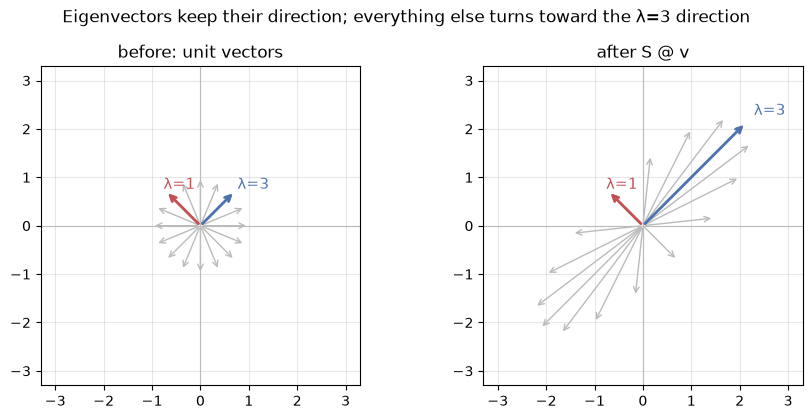

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
units = np.stack([np.cos(angles), np.sin(angles)])
moved = S @ units
for ax, pts, title in [(axes[0], units, "before: unit vectors"), (axes[1], moved, "after S @ v")]:
    for k in range(pts.shape[1]):
        ax.annotate("", xy=pts[:, k], xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="#BBBBBB"))
    draw_arrows(ax, [eigvecs[:, 0] * (1 if ax is axes[0] else eigvals[0]), eigvecs[:, 1] * (1 if ax is axes[0] else eigvals[1])],
                ["#C44E52", "#4C72B0"], [f"λ={eigvals[0]:.0f}", f"λ={eigvals[1]:.0f}"], lim=3.3)
    ax.set_title(title)
fig.suptitle("Eigenvectors keep their direction; everything else turns toward the λ=3 direction")
plt.tight_layout()
plt.show()

**Why ML cares:** the eigenvectors of a **covariance matrix** are the directions in which data varies most, and the eigenvalues are *how much* variance lies along each — that's PCA. Eigenvalues also describe curvature (Hessian, Section 13), the long-run behaviour of Markov chains (PageRank), and whether repeated multiplication explodes or vanishes (RNN gradients).

### ✍️ Your Turn

Find the **largest eigenvalue** of the covariance matrix of the iris features. (Use `np.cov(X_iris, rowvar=False)` and `np.linalg.eigh`.)

In [19]:
largest_eigenvalue = None  # TODO
check("iris_top_eigenvalue", largest_eigenvalue, 4.228241706034867, hint="eigh returns eigenvalues in ascending order — take the last one.")

⏳ iris_top_eigenvalue: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cov = np.cov(X_iris, rowvar=False)          # (4, 4); rowvar=False → columns are variables
largest_eigenvalue = np.linalg.eigh(cov).eigenvalues[-1]
check("iris_top_eigenvalue", largest_eigenvalue, 4.228241706034867)
```

Its share of the total, `largest / eigenvalues.sum()` ≈ 92%, is PCA's "explained variance ratio" of the first component.
</details>

> 💡 **Interview angle:** "What do eigenvalues of a covariance matrix mean?" — each eigenvalue is the variance of the data along its eigenvector; sorting them descending ranks the principal directions, and their sum equals the total variance (trace of the covariance).

## 8. SVD and PCA 🔴

**Singular Value Decomposition** splits *any* matrix (any shape, not just square) into three simple steps:

$$X = U \, \Sigma \, V^\top \quad\text{→}\quad \text{rotate } (V^\top) \;→\; \text{stretch along axes } (\Sigma) \;→\; \text{rotate } (U)$$

- $\Sigma$ holds the **singular values** $s_1 \ge s_2 \ge \dots \ge 0$ — how important each direction is.
- Keeping only the top-$k$ singular values gives the **best possible rank-$k$ approximation** of $X$ (the Eckart–Young theorem).

**PCA (Principal Component Analysis)** finds new axes — *principal components* — ordered by how much variance they capture. Recipe:

```
1. Center the data: subtract each column's mean       (optionally scale each column to unit variance)
2. SVD of the centered data:  Xc = U Σ Vᵀ
3. Rows of Vᵀ = principal directions;  variance along each = s² / (n − 1)
4. Project: Z = Xc @ V[:, :k]   (= U[:, :k] Σ[:k])   → k numbers per sample instead of d
```

**SVD vs eigendecomposition:** PCA can also be done by eigendecomposition of the covariance matrix $X_c^\top X_c/(n-1)$ — its eigenvectors are $V$ and eigenvalues are $s^2/(n-1)$. SVD works on the data directly, never forms $X^\top X$ (which squares the condition number), and works for any rectangular matrix.

In [20]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data                         # (1797, 64): 8×8 pixel intensities 0–16, real handwritten digits
Xc = X_digits - X_digits.mean(axis=0)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
print("U", U.shape, "| s", s.shape, "| Vt", Vt.shape)
print("reconstruction U Σ Vᵀ == Xc:", np.allclose(U * s @ Vt, Xc))

# SVD and eigendecomposition of the covariance agree
cov = Xc.T @ Xc / (len(Xc) - 1)
eig_desc = np.linalg.eigh(cov).eigenvalues[::-1]
print("s²/(n−1) == eigenvalues of covariance:", np.allclose(s ** 2 / (len(Xc) - 1), eig_desc))

explained = s ** 2 / np.sum(s ** 2)
cumulative = np.cumsum(explained)
k90 = int(np.searchsorted(cumulative, 0.90) + 1)
print(f"first 2 components explain {cumulative[1]:.1%} of variance; {k90} of 64 components are needed for 90%")

U (1797, 64) | s (64,) | Vt (64, 64)


reconstruction U Σ Vᵀ == Xc: True
s²/(n−1) == eigenvalues of covariance: True
first 2 components explain 28.5% of variance; 21 of 64 components are needed for 90%


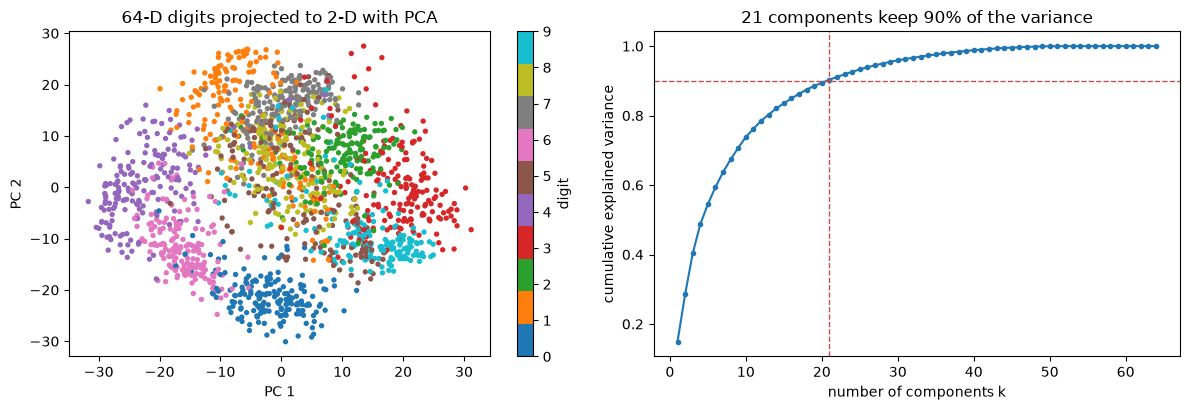

In [21]:
Z = Xc @ Vt[:2].T                              # project onto the first 2 principal components
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sc = axes[0].scatter(Z[:, 0], Z[:, 1], c=digits.target, cmap="tab10", s=8)
axes[0].set(xlabel="PC 1", ylabel="PC 2", title="64-D digits projected to 2-D with PCA")
fig.colorbar(sc, ax=axes[0], label="digit")
axes[1].plot(np.arange(1, 65), cumulative, marker=".")
axes[1].axhline(0.9, color="#C44E52", ls="--", lw=1)
axes[1].axvline(k90, color="#C44E52", ls="--", lw=1)
axes[1].set(xlabel="number of components k", ylabel="cumulative explained variance", title=f"{k90} components keep 90% of the variance")
plt.tight_layout()
plt.show()

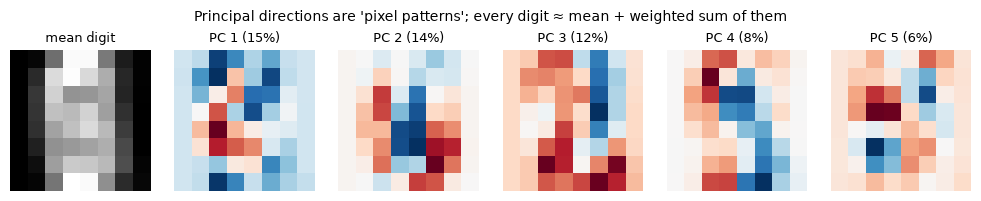

In [22]:
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
axes[0].imshow(X_digits.mean(axis=0).reshape(8, 8), cmap="gray")
axes[0].set_title("mean digit", fontsize=9)
for i in range(5):
    axes[i + 1].imshow(Vt[i].reshape(8, 8), cmap="RdBu")
    axes[i + 1].set_title(f"PC {i + 1} ({explained[i]:.0%})", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.suptitle("Principal directions are 'pixel patterns'; every digit ≈ mean + weighted sum of them", fontsize=10)
plt.tight_layout()
plt.show()

**PCA assumptions and limits** (interviewers ask): it finds **linear** structure only; it assumes directions of **large variance are important** (not always true — noise can have high variance); it is **sensitive to feature scale** (standardize features measured in different units — see Pitfalls); it's sensitive to outliers; and the components are orthogonal, which may not match real underlying factors.

### ✍️ Your Turn

Using `cumulative` from above, how many components are needed to keep **at least 95%** of the variance of the digits?

In [23]:
k95 = None  # TODO
check("k_for_95", k95, int(np.argmax(np.cumsum(np.linalg.svd(X_digits - X_digits.mean(0), compute_uv=False) ** 2) / np.sum(np.linalg.svd(X_digits - X_digits.mean(0), compute_uv=False) ** 2) >= 0.95) + 1),
      hint="np.searchsorted(cumulative, 0.95) + 1, or the first index where cumulative >= 0.95, plus 1.")

⏳ k_for_95: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
k95 = int(np.argmax(cumulative >= 0.95) + 1)       # first position reaching 95%, converted from 0-based index to a count
check("k_for_95", k95, int(np.searchsorted(cumulative, 0.95) + 1))
print(k95)
```

scikit-learn does this for you: `PCA(n_components=0.95)` keeps just enough components for 95% of the variance.
</details>

> 💡 **Interview angle:** "Walk me through PCA." — center (and usually standardize) → SVD of the data (or eigendecomposition of the covariance) → sort directions by variance → keep top-k by explained variance → project. Mention that `fit` must happen on **training data only**, then `transform` validation and test data.

## 9. Derivatives and Partial Derivatives 🟢

A **derivative** is a slope: *if I nudge the input a tiny bit, how much does the output change?*

$$f'(x) \approx \frac{f(x + h) - f(x)}{h} \quad \text{for a tiny } h$$

Rules you'll actually use: $(x^n)' = n x^{n-1}$, $(e^x)' = e^x$, $(\ln x)' = 1/x$, and sums differentiate term by term.

A **partial derivative** $\partial f / \partial x$ is the slope in one input while holding the others fixed — like walking due east on a hillside and measuring only that slope.

Three ways to get a derivative, all used in practice:
1. **By hand** (understanding)
2. **Symbolically** with SymPy (exact formulas)
3. **Numerically** with tiny nudges (checking) — and, inside PyTorch/JAX, **automatic differentiation** (Section 10)

In [24]:
x_sym, y_sym = sp.symbols("x y")
f_sym = x_sym ** 3 - 2 * x_sym + sp.exp(x_sym)
df_sym = sp.diff(f_sym, x_sym)
print("f(x)  =", f_sym)
print("f'(x) =", df_sym)

f_num = sp.lambdify(x_sym, f_sym, "numpy")        # turn the formula into a fast NumPy function
df_num = sp.lambdify(x_sym, df_sym, "numpy")
x0, h = 1.0, 1e-5
forward = (f_num(x0 + h) - f_num(x0)) / h
central = (f_num(x0 + h) - f_num(x0 - h)) / (2 * h)
print(f"\nat x={x0}: exact {df_num(x0):.10f} | forward difference {forward:.10f} | central difference {central:.10f}")
print(f"errors → forward {abs(forward - df_num(x0)):.1e}, central {abs(central - df_num(x0)):.1e} (central is much more accurate)")

f(x)  = x**3 - 2*x + exp(x)
f'(x) = 3*x**2 + exp(x) - 2

at x=1.0: exact 3.7182818285 | forward difference 3.7183254201 | central difference 3.7182818286
errors → forward 4.4e-05, central 1.5e-10 (central is much more accurate)


In [25]:
# Partial derivatives of a 2-input function
g_sym = x_sym ** 2 * y_sym + sp.sin(y_sym)
print("g(x, y) =", g_sym)
print("∂g/∂x   =", sp.diff(g_sym, x_sym), "  (y treated as a constant)")
print("∂g/∂y   =", sp.diff(g_sym, y_sym), "  (x treated as a constant)")

g(x, y) = x**2*y + sin(y)
∂g/∂x   = 2*x*y   (y treated as a constant)
∂g/∂y   = x**2 + cos(y)   (x treated as a constant)


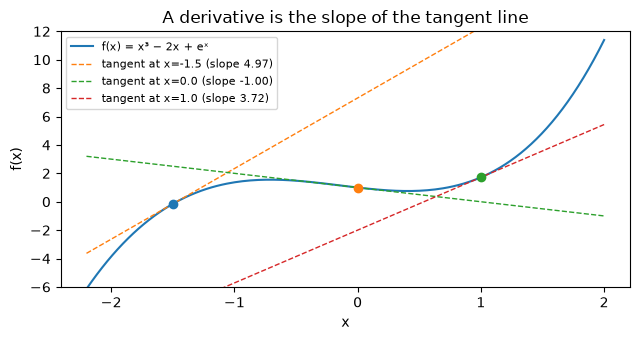

In [26]:
xs = np.linspace(-2.2, 2.0, 200)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(xs, f_num(xs), label="f(x) = x³ − 2x + eˣ")
for x_t in [-1.5, 0.0, 1.0]:
    slope = df_num(x_t)
    ax.plot(xs, f_num(x_t) + slope * (xs - x_t), "--", lw=1, label=f"tangent at x={x_t} (slope {slope:.2f})")
    ax.scatter([x_t], [f_num(x_t)], zorder=3)
ax.set(ylim=(-6, 12), xlabel="x", ylabel="f(x)", title="A derivative is the slope of the tangent line")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Estimate the derivative of $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ (the **sigmoid**) at $z = 0.5$ with a **central difference** ($h = 10^{-5}$). The exact answer is $\sigma(z)(1 - \sigma(z))$.

In [27]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


sigmoid_slope = None  # TODO: (sigmoid(0.5 + h) - sigmoid(0.5 - h)) / (2h)
check("sigmoid_derivative", sigmoid_slope, sigmoid(0.5) * (1 - sigmoid(0.5)), hint="Use h = 1e-5 and the central formula.")

⏳ sigmoid_derivative: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

h = 1e-5
sigmoid_slope = (sigmoid(0.5 + h) - sigmoid(0.5 - h)) / (2 * h)
check("sigmoid_derivative", sigmoid_slope, sigmoid(0.5) * (1 - sigmoid(0.5)))
```

The neat formula σ′ = σ(1 − σ) is why sigmoid gradients are cheap — and why they vanish: σ′ is at most 0.25 and near 0 for large |z|.
</details>

> 💡 **Interview angle:** "Derivative of the sigmoid?" — σ′(z) = σ(z)(1 − σ(z)), max 0.25 at z = 0. Follow-up: stacking many sigmoid layers multiplies these small numbers → **vanishing gradients**, one reason ReLU replaced sigmoid in hidden layers.

## 10. The Chain Rule 🟡

Functions in ML are **compositions**: input → layer → activation → loss. The **chain rule** says the slope of a chain is the **product of the slopes of its links**:

$$\frac{dL}{dx} = \frac{dL}{dy}\cdot\frac{dy}{dx} \qquad\text{e.g. } L = (\underbrace{wx + b}_{z} - t)^2$$

Analogy: if a car goes 2× faster than a bike, and the bike goes 4× faster than a walker, the car goes 2 × 4 = 8× faster than the walker.

**Backpropagation** = the chain rule applied from the loss backwards, reusing each intermediate result:

```
forward:   x ──(z = w·x + b)──▶ z ──(a = σ(z))──▶ a ──(L = (a − t)²)──▶ L
backward:  dL/dw = dL/da · da/dz · dz/dw = 2(a − t) · σ(z)(1 − σ(z)) · x
```

In [28]:
# A one-neuron "network": manual chain rule vs SymPy vs numerical check
w_s, b_s, x_s, t_s = sp.symbols("w b x t")
z_expr = w_s * x_s + b_s
a_expr = 1 / (1 + sp.exp(-z_expr))
L_expr = (a_expr - t_s) ** 2

values = {w_s: 0.8, b_s: -0.3, x_s: 1.5, t_s: 1.0}
dL_dw_sympy = float(sp.diff(L_expr, w_s).subs(values))

# Manual backprop: forward pass, keep intermediates, multiply local slopes backwards
w_v, b_v, x_v, t_v = 0.8, -0.3, 1.5, 1.0
z_v = w_v * x_v + b_v
a_v = sigmoid(z_v)
L_v = (a_v - t_v) ** 2
dL_da = 2 * (a_v - t_v)
da_dz = a_v * (1 - a_v)
dz_dw = x_v
dL_dw_manual = dL_da * da_dz * dz_dw

loss_of_w = lambda w_: (sigmoid(w_ * x_v + b_v) - t_v) ** 2
dL_dw_numeric = (loss_of_w(w_v + 1e-6) - loss_of_w(w_v - 1e-6)) / 2e-6

print(f"forward: z={z_v:.3f}  a={a_v:.4f}  L={L_v:.4f}")
print(f"local slopes: dL/da={dL_da:.4f}  da/dz={da_dz:.4f}  dz/dw={dz_dw:.1f}")
print(f"dL/dw → chain rule {dL_dw_manual:.6f} | SymPy {dL_dw_sympy:.6f} | numerical {dL_dw_numeric:.6f}")
assert np.isclose(dL_dw_manual, dL_dw_sympy) and np.isclose(dL_dw_manual, dL_dw_numeric)

forward: z=0.900  a=0.7109  L=0.0836
local slopes: dL/da=-0.5781  da/dz=0.2055  dz/dw=1.5
dL/dw → chain rule -0.178200 | SymPy -0.178200 | numerical -0.178200


**Why backprop is efficient:** a network with a million weights needs a million partial derivatives. Nudging each weight numerically would take a million forward passes. Backprop gets **all of them in about one forward + one backward pass**, because the upstream factor (`dL/da · da/dz`) is shared by every weight feeding that neuron. Frameworks do this automatically (**reverse-mode autodiff**).

### ✍️ Your Turn

Using the forward values above, compute **dL/db** with the chain rule. (Hint: $z = wx + b$, so $dz/db = 1$.)

In [29]:
dL_db = None  # TODO: reuse dL_da and da_dz
check("chain_rule_bias", dL_db, float(sp.diff(L_expr, b_s).subs(values)), hint="dL/db = dL/da · da/dz · dz/db, with dz/db = 1.")

⏳ chain_rule_bias: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dL_db = dL_da * da_dz * 1.0
check("chain_rule_bias", dL_db, float(sp.diff(L_expr, b_s).subs(values)))
```

Notice we reused `dL_da * da_dz` from the weight gradient — that sharing is the whole point of backpropagation.
</details>

> 💡 **Interview angle:** "Explain backpropagation in one sentence." — it applies the chain rule from the loss back through the computation graph, multiplying local derivatives and reusing shared intermediate results, so all parameter gradients cost roughly one extra backward pass.

## 11. Gradients and Numerical Gradient Checking 🟡

The **gradient** $\nabla f$ collects all partial derivatives into one vector. It points in the direction of **steepest ascent** — the way uphill is steepest — and its length is how steep that is. So $-\nabla f$ points steepest **downhill**, which is where gradient descent steps.

Picture a contour map of a hill: the gradient arrow is always **perpendicular to the contour lines**, pointing to higher ground.

**Gradient checking** compares your analytic gradient with a numerical one (central differences on each input). If they disagree, your backprop code has a bug. The standard metric is the **relative error** $\dfrac{\lVert g_{analytic} - g_{numeric} \rVert}{\lVert g_{analytic} \rVert + \lVert g_{numeric} \rVert}$: around 1e-7 or smaller is good; 1e-2 or bigger means a bug.

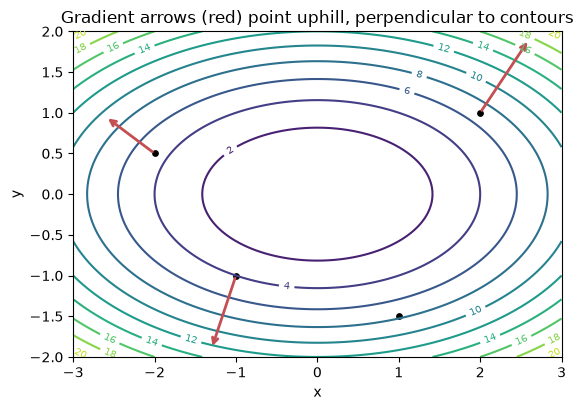

In [30]:
def bowl(p):                                   # f(x, y) = x² + 3y²  (an elongated bowl)
    return p[0] ** 2 + 3 * p[1] ** 2


def bowl_grad(p):
    return np.array([2 * p[0], 6 * p[1]])


gx2, gy2 = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2, 200))
fig, ax = plt.subplots(figsize=(6.5, 4.2))
cs = ax.contour(gx2, gy2, gx2 ** 2 + 3 * gy2 ** 2, levels=12, cmap="viridis")
ax.clabel(cs, fontsize=7)
for p in [np.array([2.0, 1.0]), np.array([-2.0, 0.5]), np.array([1.0, -1.5]), np.array([-1.0, -1.0])]:
    g = bowl_grad(p)
    ax.annotate("", xy=p + 0.15 * g, xytext=p, arrowprops=dict(arrowstyle="->", color="#C44E52", lw=2))
    ax.scatter(*p, color="black", s=15)
ax.set(aspect="equal", title="Gradient arrows (red) point uphill, perpendicular to contours", xlabel="x", ylabel="y")
plt.tight_layout()
plt.show()

In [31]:
def numerical_gradient(f, p, h=1e-5):
    """Central-difference gradient of scalar function f at point p (any shape)."""
    p = np.asarray(p, dtype=float)
    grad = np.zeros_like(p)
    for idx in np.ndindex(p.shape):
        step = np.zeros_like(p)
        step[idx] = h
        grad[idx] = (f(p + step) - f(p - step)) / (2 * h)
    return grad


def relative_error(g1, g2):
    return np.linalg.norm(g1 - g2) / (np.linalg.norm(g1) + np.linalg.norm(g2) + 1e-12)


p_test = np.array([1.3, -0.7])
print("analytic :", bowl_grad(p_test))
print("numerical:", numerical_gradient(bowl, p_test))
print(f"relative error: {relative_error(bowl_grad(p_test), numerical_gradient(bowl, p_test)):.1e}")

buggy_grad = lambda p: np.array([2 * p[0], 3 * p[1]])   # forgot the factor 2 from d(3y²)/dy
print(f"buggy gradient relative error: {relative_error(buggy_grad(p_test), numerical_gradient(bowl, p_test)):.1e} → bug detected")

analytic : [ 2.6 -4.2]
numerical: [ 2.6 -4.2]
relative error: 3.3e-12
buggy gradient relative error: 2.5e-01 → bug detected


> 💡 **Interview angle:** "How do you know your custom backward pass is right?" — gradient check: central differences on a few random parameters in float64, compare with relative error, and avoid non-differentiable points (like ReLU at exactly 0) and randomness (dropout off) during the check.

## 12. Gradient Descent and Learning Rates 🟡

**Gradient descent** repeats one step: $\;p \leftarrow p - \eta\, \nabla f(p)$, where the **learning rate** $\eta$ is the step size. Like walking downhill in fog: feel the slope under your feet, take a step downhill, repeat.

- $\eta$ too small → painfully slow
- $\eta$ just right → fast convergence
- $\eta$ too large → overshoots, oscillates, or **diverges** (loss grows to infinity)

For the bowl $x^2 + 3y^2$, the steepest direction has curvature 6, so any $\eta > 2/6 \approx 0.333$ diverges along $y$.

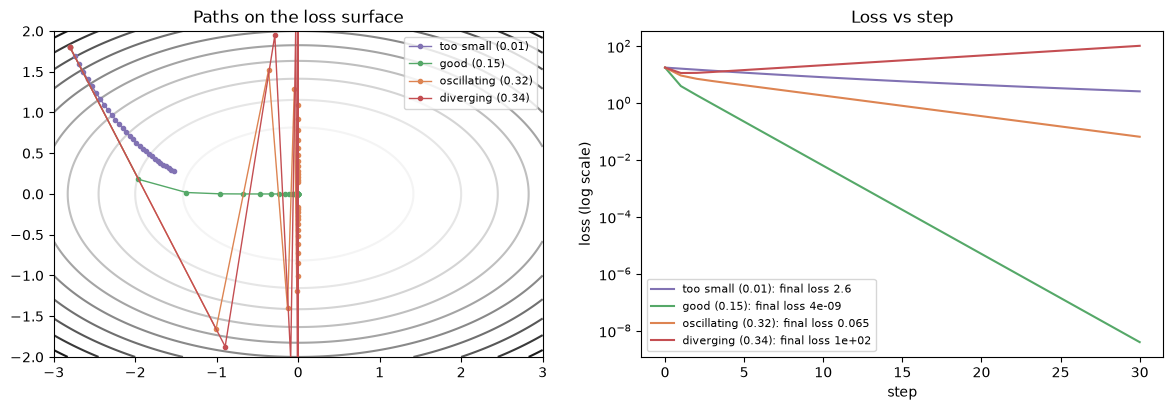

In [32]:
def gradient_descent(grad_fn, start, lr, steps):
    path = [np.array(start, dtype=float)]
    for _ in range(steps):
        path.append(path[-1] - lr * grad_fn(path[-1]))
    return np.array(path)


start = [-2.8, 1.8]
learning_rates = {"too small (0.01)": 0.01, "good (0.15)": 0.15, "oscillating (0.32)": 0.32, "diverging (0.34)": 0.34}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].contour(gx2, gy2, gx2 ** 2 + 3 * gy2 ** 2, levels=12, cmap="Greys")
for (name, lr), color in zip(learning_rates.items(), ["#8172B3", "#55A868", "#DD8452", "#C44E52"]):
    path = gradient_descent(bowl_grad, start, lr, 30)
    losses = np.array([bowl(p) for p in path])
    shown = path[np.all(np.abs(path) < 4, axis=1)]
    axes[0].plot(shown[:, 0], shown[:, 1], ".-", color=color, label=name, lw=1)
    axes[1].semilogy(losses, color=color, label=f"{name}: final loss {losses[-1]:.2g}")
axes[0].set(xlim=(-3, 3), ylim=(-2, 2), aspect="equal", title="Paths on the loss surface")
axes[1].set(xlabel="step", ylabel="loss (log scale)", title="Loss vs step")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Convex vs non-convex.** The bowl is **convex**: one valley, so gradient descent with a sensible learning rate reaches the global minimum from anywhere. Neural-network losses are **non-convex**: many valleys, and where you end up depends on where you start.

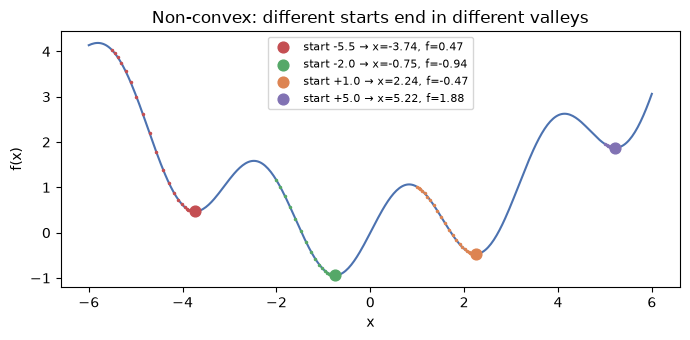

4 different end points; the lowest (f=-0.941) came from start -2.0


In [33]:
def wavy(x):                                    # a non-convex 1-D function
    return 0.1 * x ** 2 + np.sin(2 * x)


def wavy_grad(x):
    return 0.2 * x + 2 * np.cos(2 * x)


xs_w = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(xs_w, wavy(xs_w), color="#4C72B0")
results_nc = []
for x_start, color in zip([-5.5, -2.0, 1.0, 5.0], ["#C44E52", "#55A868", "#DD8452", "#8172B3"]):
    path = gradient_descent(wavy_grad, [x_start], lr=0.05, steps=200)[:, 0]
    results_nc.append((x_start, path[-1], wavy(path[-1])))
    ax.plot(path, wavy(path), ".", color=color, ms=3)
    ax.scatter([path[-1]], [wavy(path[-1])], color=color, s=60, zorder=3, label=f"start {x_start:+.1f} → x={path[-1]:.2f}, f={wavy(path[-1]):.2f}")
ax.set(xlabel="x", ylabel="f(x)", title="Non-convex: different starts end in different valleys")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
best = min(results_nc, key=lambda r: r[2])
print(f"{len({round(r[1], 2) for r in results_nc})} different end points; the lowest (f={best[2]:.3f}) came from start {best[0]:+.1f}")

In practice deep learning copes with non-convexity using good initialization, momentum/Adam, learning-rate schedules and noise from mini-batches — and in very high dimensions most bad critical points are **saddle points** rather than poor local minima.

> 💡 **Interview angle:** "Your training loss explodes to NaN after a few steps — what do you try first?" — lower the learning rate (or add warmup), check for gradient explosion (clip gradients), check input scaling, and look for `log(0)`/division by zero in the loss.

## 13. Jacobians, Hessians, and Convexity 🔴

- **Jacobian** $J$ — for a function with **vector outputs**, the matrix of all first derivatives: `J[i, j] = ∂output_i / ∂input_j`. Shape `(n_outputs, n_inputs)`. Backprop chains Jacobians together (but never builds them in full — it multiplies vectors by them).
- **Hessian** $H$ — for a **scalar** function, the matrix of second derivatives `H[i, j] = ∂²f / ∂x_i ∂x_j`. It describes **curvature**: how the slope itself changes.
- **Convexity:** a twice-differentiable function is convex exactly when its Hessian is **positive semi-definite** everywhere (all eigenvalues ≥ 0) — it curves up in every direction, like a bowl. Convex ⇒ every local minimum is a global minimum.

| Hessian eigenvalues at a critical point | Shape |
|---|---|
| all > 0 | minimum (bowl) |
| all < 0 | maximum (dome) |
| mixed signs | **saddle** (like a horse saddle / Pringle) |

In [34]:
# Jacobian of softmax (vector in → vector out), SymPy vs the known formula diag(p) − p pᵀ
z1, z2, z3 = sp.symbols("z1 z2 z3")
zs = sp.Matrix([z1, z2, z3])
softmax_sym = sp.Matrix([sp.exp(zi) for zi in zs]) / sum(sp.exp(zi) for zi in zs)
J_sym = softmax_sym.jacobian(zs)

z_point = {z1: 1.0, z2: 2.0, z3: 0.5}
J_num = np.array(J_sym.subs(z_point).evalf(), dtype=float)
logits = np.array([1.0, 2.0, 0.5])
probs = np.exp(logits) / np.exp(logits).sum()
J_formula = np.diag(probs) - np.outer(probs, probs)
print("softmax Jacobian (3×3):\n", J_num)
print("matches diag(p) − p pᵀ:", np.allclose(J_num, J_formula), "| each row sums to 0:", np.allclose(J_num.sum(axis=1), 0))

softmax Jacobian (3×3):
 [[ 0.178 -0.145 -0.032]
 [-0.145  0.233 -0.088]
 [-0.032 -0.088  0.121]]
matches diag(p) − p pᵀ: True | each row sums to 0: True


In [35]:
# Hessians: bowl (convex), saddle, and the log-loss of logistic regression
f_bowl = x_sym ** 2 + 3 * y_sym ** 2
f_saddle = x_sym ** 2 - y_sym ** 2
for name, expr in [("bowl x² + 3y²", f_bowl), ("saddle x² − y²", f_saddle)]:
    H = np.array(sp.hessian(expr, (x_sym, y_sym)), dtype=float)
    eig = np.linalg.eigvalsh(H)
    kind = "convex (minimum)" if np.all(eig > 0) else "saddle" if eig.min() < 0 < eig.max() else "other"
    print(f"{name:16s} Hessian eigenvalues {eig} → {kind}")

# Logistic-regression loss Hessian is Xᵀ diag(p(1−p)) X / n → always positive semi-definite → convex
X_lr = rng.normal(size=(200, 3))
w_lr = rng.normal(size=3)
p_lr = sigmoid(X_lr @ w_lr)
H_lr = X_lr.T @ (X_lr * (p_lr * (1 - p_lr))[:, None]) / len(X_lr)
print(f"logistic loss Hessian eigenvalues at a random w: {np.linalg.eigvalsh(H_lr)} → all ≥ 0: {np.all(np.linalg.eigvalsh(H_lr) >= -1e-12)}")

bowl x² + 3y²    Hessian eigenvalues [2. 6.] → convex (minimum)
saddle x² − y²   Hessian eigenvalues [-2.  2.] → saddle
logistic loss Hessian eigenvalues at a random w: [0.163 0.237 0.262] → all ≥ 0: True


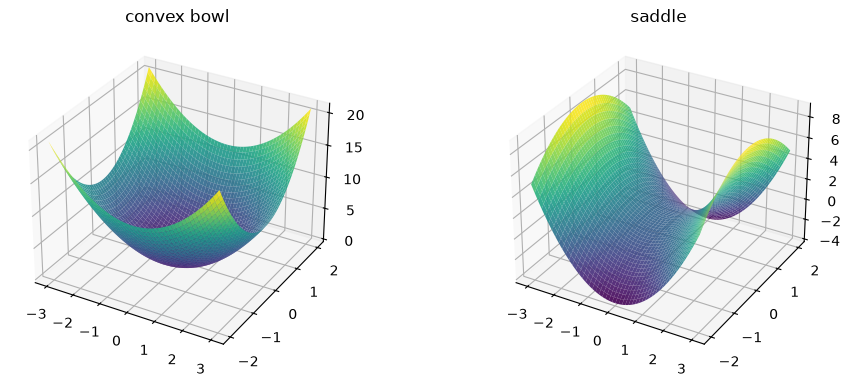

In [36]:
fig = plt.figure(figsize=(10, 4))
for k, (name, surf) in enumerate([("convex bowl", gx2 ** 2 + 3 * gy2 ** 2), ("saddle", gx2 ** 2 - gy2 ** 2)]):
    ax3 = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax3.plot_surface(gx2, gy2, surf, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax3.set_title(name)
plt.tight_layout()
plt.show()

**Why curvature matters for training:** the Hessian's largest eigenvalue sets the maximum stable learning rate (the 2/6 limit in Section 12), and a big ratio between largest and smallest eigenvalues (**ill-conditioning**) makes gradient descent zig-zag. Standardizing features, momentum and Adam all help with that. Full Newton's method uses $H^{-1}$ but is too expensive for millions of parameters.

> 💡 **Interview angle:** "Is logistic regression's loss convex? Is a neural network's?" — logistic regression: yes (Hessian $X^\top \text{diag}(p(1-p)) X$ is PSD), so any local minimum is global. Neural networks: no — hidden layers and non-linearities create many minima and saddle points.

## 14. Information Theory for ML 🟡

**Surprise.** An event with probability $p$ carries $-\log p$ "surprise": a sure thing (p = 1) is 0 surprise; a 1-in-1000 event is large. Using $\log_2$ measures it in **bits**; natural log $\ln$ gives **nats** (what ML libraries use).

| Quantity | Formula | Plain meaning |
|---|---|---|
| **Entropy** $H(p)$ | $-\sum_i p_i \log p_i$ | average surprise of outcomes from $p$ — how uncertain $p$ is |
| **Cross-entropy** $H(p, q)$ | $-\sum_i p_i \log q_i$ | average surprise if reality is $p$ but you *believe* $q$ |
| **KL divergence** $D_{KL}(p \Vert q)$ | $\sum_i p_i \log \dfrac{p_i}{q_i} = H(p,q) - H(p)$ | the *extra* surprise from using $q$ instead of $p$; ≥ 0, = 0 only if $q = p$ |

**The link to classification:** the true label is a one-hot $p$ (entropy 0), so cross-entropy loss = $-\log q_{\text{true class}}$ = KL divergence to the truth. Minimizing cross-entropy = maximizing the likelihood of the correct labels.

fair coin          entropy = 1.000 bits
biased coin 90/10  entropy = 0.469 bits
certain            entropy = 0.000 bits
fair 8-sided die   entropy = 3.000 bits


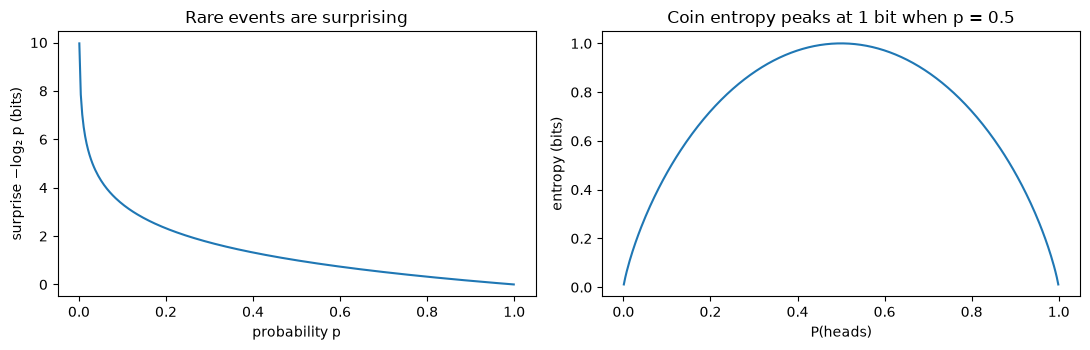

In [37]:
def entropy_bits(p):
    p = np.asarray(p, dtype=float)
    nz = p > 0                                   # 0 · log 0 is defined as 0
    return float(-np.sum(p[nz] * np.log2(p[nz]))) + 0.0      # + 0.0 turns IEEE "-0.0" into 0.0


for name, dist in [("fair coin", [0.5, 0.5]), ("biased coin 90/10", [0.9, 0.1]), ("certain", [1.0, 0.0]),
                   ("fair 8-sided die", [1 / 8] * 8)]:
    print(f"{name:18s} entropy = {entropy_bits(dist):.3f} bits")

ps = np.linspace(0.001, 0.999, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(ps, -np.log2(ps))
axes[0].set(xlabel="probability p", ylabel="surprise −log₂ p (bits)", title="Rare events are surprising")
axes[1].plot(ps, -(ps * np.log2(ps) + (1 - ps) * np.log2(1 - ps)))
axes[1].set(xlabel="P(heads)", ylabel="entropy (bits)", title="Coin entropy peaks at 1 bit when p = 0.5")
plt.tight_layout()
plt.show()

In [38]:
from scipy.stats import entropy as scipy_entropy

p_true = np.array([0.7, 0.2, 0.1])
q_model = np.array([0.5, 0.3, 0.2])

H_p = -np.sum(p_true * np.log(p_true))
H_pq = -np.sum(p_true * np.log(q_model))
KL_pq = np.sum(p_true * np.log(p_true / q_model))
KL_qp = np.sum(q_model * np.log(q_model / p_true))
print(f"H(p) = {H_p:.4f} nats | H(p, q) = {H_pq:.4f} | KL(p‖q) = {KL_pq:.4f} = H(p,q) − H(p): {np.isclose(KL_pq, H_pq - H_p)}")
print(f"KL(q‖p) = {KL_qp:.4f} → KL is NOT symmetric (KL(p‖q) ≠ KL(q‖p))")
assert np.isclose(KL_pq, scipy_entropy(p_true, q_model)) and np.isclose(H_p, scipy_entropy(p_true))

H(p) = 0.8018 nats | H(p, q) = 0.8869 | KL(p‖q) = 0.0851 = H(p,q) − H(p): True
KL(q‖p) = 0.0920 → KL is NOT symmetric (KL(p‖q) ≠ KL(q‖p))


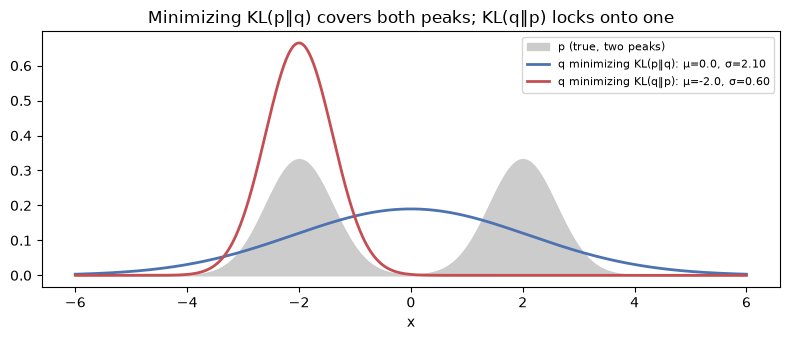

{'KL(p‖q)': 'mu=0.00, sd=2.10', 'KL(q‖p)': 'mu=-2.00, sd=0.60'}


In [39]:
# KL asymmetry, visually: fit one Gaussian q to a two-peaked p by minimizing each direction of KL
grid = np.linspace(-6, 6, 1201)
dx = grid[1] - grid[0]


def gauss(x, mu, sd):
    return np.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))


p_bimodal = 0.5 * gauss(grid, -2, 0.6) + 0.5 * gauss(grid, 2, 0.6)
best = {}
for direction in ["KL(p‖q)", "KL(q‖p)"]:
    scores = []
    for mu in np.linspace(-3, 3, 61):
        for sd in np.linspace(0.3, 3.5, 65):
            q = gauss(grid, mu, sd) + 1e-300
            pp = p_bimodal + 1e-300
            kl = np.sum(pp * np.log(pp / q)) * dx if direction == "KL(p‖q)" else np.sum(q * np.log(q / pp)) * dx
            scores.append((kl, mu, sd))
    best[direction] = min(scores)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(grid, p_bimodal, color="#CCCCCC", label="p (true, two peaks)")
for (direction, (kl, mu, sd)), color in zip(best.items(), ["#4C72B0", "#C44E52"]):
    ax.plot(grid, gauss(grid, mu, sd), color=color, lw=2, label=f"q minimizing {direction}: μ={mu:.1f}, σ={sd:.2f}")
ax.set(title="Minimizing KL(p‖q) covers both peaks; KL(q‖p) locks onto one", xlabel="x")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print({d: f"mu={m:.2f}, sd={s:.2f}" for d, (_, m, s) in best.items()})

**Forward KL** $D_{KL}(p\Vert q)$ is "mean-seeking / mass-covering": $q$ must put probability wherever $p$ does, so it spreads over both peaks (this is what maximum-likelihood training minimizes). **Reverse KL** $D_{KL}(q\Vert p)$ is "mode-seeking": $q$ is punished for putting mass where $p$ has none, so it picks one peak (variational inference; the KL penalty in RLHF is taken as KL(policy ‖ reference)).

### ✍️ Your Turn

Compute the **KL divergence** $D_{KL}(p \Vert q)$ in **nats** for $p = [0.5, 0.5]$ and $q = [0.9, 0.1]$.

In [40]:
p_coin = np.array([0.5, 0.5])
q_coin = np.array([0.9, 0.1])
kl_coin = None  # TODO
check("kl_divergence", kl_coin, 0.5108256237659907, hint="np.sum(p * np.log(p / q))")

⏳ kl_divergence: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_coin = np.array([0.5, 0.5])
q_coin = np.array([0.9, 0.1])
kl_coin = np.sum(p_coin * np.log(p_coin / q_coin))
check("kl_divergence", kl_coin, 0.5108256237659907)
```

Swap the arguments and you get ≈ 0.368 — a different number, because KL is not a distance.
</details>

> 💡 **Interview angle:** "Why cross-entropy instead of MSE for classification?" — with sigmoid/softmax outputs, cross-entropy is the negative log-likelihood (a proper probabilistic loss), it is convex for logistic regression, and its gradient w.r.t. logits is simply `p − y`, so confident wrong predictions get large gradients; MSE's gradient is multiplied by σ′ and vanishes when the model is confidently wrong.

## 🔧 Build It From Scratch

Three classics interviewers love, each `assert`-ed against a library.

### 1) PCA via SVD, matching `sklearn.decomposition.PCA`

**The sign-flip catch:** an eigenvector/singular vector $v$ and $-v$ are equally valid, so two correct implementations can disagree in sign. scikit-learn makes the result deterministic with `svd_flip`: in recent versions it flips each component so that its **largest-magnitude entry is positive**. We apply the same rule, and also show a sign-agnostic comparison that works against any implementation.

In [41]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        U, s, Vt = np.linalg.svd(X - self.mean_, full_matrices=False)
        # deterministic signs: make the largest-|value| entry of each component positive
        signs = np.sign(Vt[np.arange(len(Vt)), np.abs(Vt).argmax(axis=1)])
        Vt = Vt * signs[:, None]
        k = self.n_components
        self.components_ = Vt[:k]                                   # (k, n_features)
        variances = s ** 2 / (len(X) - 1)
        self.explained_variance_ = variances[:k]
        self.explained_variance_ratio_ = variances[:k] / variances.sum()
        return self

    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.mean_) @ self.components_.T

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_


X_tr_d, X_te_d = train_test_split(X_digits, test_size=0.25, random_state=0)
ours = PCAFromScratch(n_components=10).fit(X_tr_d)                  # fit on TRAIN only
sk = PCA(n_components=10, svd_solver="full").fit(X_tr_d)

assert np.allclose(ours.components_, sk.components_), "components differ"
assert np.allclose(ours.explained_variance_, sk.explained_variance_)
assert np.allclose(ours.explained_variance_ratio_, sk.explained_variance_ratio_)
assert np.allclose(ours.transform(X_te_d), sk.transform(X_te_d))    # transform unseen TEST data
assert np.allclose(ours.inverse_transform(ours.transform(X_te_d)), sk.inverse_transform(sk.transform(X_te_d)))

# Sign-agnostic check: |cosine| between matching components is 1 no matter which sign convention was used
flipped = -ours.components_
abs_cos = np.abs(np.sum(flipped * sk.components_, axis=1))
print("✅ components, variances, transform and inverse_transform all match scikit-learn")
print("|cos| between sign-flipped ours and sklearn, per component:", abs_cos.round(6))
print(f"10 components keep {ours.explained_variance_ratio_.sum():.1%} of the training variance")

test_err = np.mean((X_te_d - ours.inverse_transform(ours.transform(X_te_d))) ** 2)
print(f"test reconstruction MSE with 10 of 64 dims: {test_err:.2f} (pixel values range 0–16; variance per pixel ≈ {X_te_d.var(axis=0).mean():.2f})")

✅ components, variances, transform and inverse_transform all match scikit-learn
|cos| between sign-flipped ours and sklearn, per component: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
10 components keep 74.1% of the training variance
test reconstruction MSE with 10 of 64 dims: 5.15 (pixel values range 0–16; variance per pixel ≈ 18.75)


### 2) A gradient checker for a real two-layer neural network

We write the forward pass and the **backward pass by hand** (chain rule) for a tiny network on real digit images, then check every one of its ~600 gradients numerically.

```
X (n, 64) → z1 = X W1ᵀ + b1 → h = tanh(z1) → logits = h W2ᵀ + b2 → softmax → cross-entropy loss
```

In [42]:
def init_params(n_in, n_hidden, n_out, seed=0):
    g = np.random.default_rng(seed)
    return {"W1": g.normal(0, 0.1, (n_hidden, n_in)), "b1": np.zeros(n_hidden),
            "W2": g.normal(0, 0.1, (n_out, n_hidden)), "b2": np.zeros(n_out)}


def forward_loss(params, X, y):
    h = np.tanh(X @ params["W1"].T + params["b1"])
    logits = h @ params["W2"].T + params["b2"]
    logits = logits - logits.max(axis=1, keepdims=True)              # stable log-softmax
    log_probs = logits - np.log(np.exp(logits).sum(axis=1, keepdims=True))
    return -log_probs[np.arange(len(y)), y].mean(), (h, np.exp(log_probs))


def backward(params, X, y):
    _, (h, probs) = forward_loss(params, X, y)
    n = len(y)
    d_logits = probs.copy()
    d_logits[np.arange(n), y] -= 1                                    # softmax + cross-entropy → p − y
    d_logits /= n
    grads = {"W2": d_logits.T @ h, "b2": d_logits.sum(axis=0)}
    d_h = d_logits @ params["W2"]
    d_z1 = d_h * (1 - h ** 2)                                         # tanh' = 1 − tanh²
    grads["W1"] = d_z1.T @ X
    grads["b1"] = d_z1.sum(axis=0)
    return grads


def gradient_check(params, X, y, h=1e-5):
    analytic = backward(params, X, y)
    report = {}
    for name, value in params.items():
        numeric = np.zeros_like(value)
        for idx in np.ndindex(value.shape):
            original = value[idx]
            value[idx] = original + h
            loss_plus, _ = forward_loss(params, X, y)
            value[idx] = original - h
            loss_minus, _ = forward_loss(params, X, y)
            value[idx] = original                                     # restore!
            numeric[idx] = (loss_plus - loss_minus) / (2 * h)
        report[name] = relative_error(analytic[name], numeric)
    return report


X_small_nn = X_digits[:40] / 16.0                                     # real images, scaled to [0, 1]
y_small_nn = digits.target[:40]
params = init_params(64, 8, 10)
n_params = sum(p.size for p in params.values())
errors = gradient_check(params, X_small_nn, y_small_nn)
print(f"checked all {n_params} parameters numerically")
for name, err in errors.items():
    print(f"  {name}: relative error {err:.2e} {'✅' if err < 1e-6 else '❌'}")
assert max(errors.values()) < 1e-6

# Now plant a classic bug (forget the tanh derivative) and watch the checker catch it
def backward_buggy(params, X, y):
    grads = backward(params, X, y)
    _, (h, probs) = forward_loss(params, X, y)
    d_logits = probs.copy()
    d_logits[np.arange(len(y)), y] -= 1
    d_logits /= len(y)
    grads["W1"] = (d_logits @ params["W2"]).T @ X                     # ❌ missing * (1 - h**2)
    return grads


_, (h_tmp, _) = forward_loss(params, X_small_nn, y_small_nn)
numeric_W1 = numerical_gradient(lambda w: forward_loss({**params, "W1": w}, X_small_nn, y_small_nn)[0], params["W1"])
print(f"buggy W1 gradient relative error: {relative_error(backward_buggy(params, X_small_nn, y_small_nn)['W1'], numeric_W1):.2e} → bug caught")

checked all 610 parameters numerically
  W1: relative error 8.87e-10 ✅
  b1: relative error 4.96e-10 ✅
  W2: relative error 3.99e-10 ✅
  b2: relative error 2.20e-10 ✅
buggy W1 gradient relative error: 6.30e-02 → bug caught


### 3) Cross-entropy from scratch vs `sklearn.metrics.log_loss`

Multiclass cross-entropy = average of $-\log(\text{predicted probability of the true class})$. scikit-learn's `log_loss` clips probabilities to $[\varepsilon, 1-\varepsilon]$ (machine epsilon for the input dtype) so that a probability of exactly 0 doesn't produce `inf`. We match that, and also build the **logits** version with log-sum-exp, which is what deep-learning frameworks use.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


def cross_entropy_from_probs(y_true, probs):
    probs = np.asarray(probs, dtype=float)
    eps = np.finfo(probs.dtype).eps
    probs = np.clip(probs, eps, 1 - eps)
    probs = probs / probs.sum(axis=1, keepdims=True)                   # renormalize after clipping (as sklearn does)
    return float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true])))


def cross_entropy_from_logits(y_true, logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    log_probs = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))
    return float(-np.mean(log_probs[np.arange(len(y_true)), y_true]))


# Real predictions: a logistic regression on the digits (train/test split, evaluated on test)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_digits / 16.0, digits.target, test_size=0.25, random_state=0)
clf = LogisticRegression(max_iter=2000).fit(X_tr_c, y_tr_c)
proba_te = clf.predict_proba(X_te_c)
logits_te = clf.decision_function(X_te_c)

ours_ce = cross_entropy_from_probs(y_te_c, proba_te)
logit_ce = cross_entropy_from_logits(y_te_c, logits_te)
sk_ce = log_loss(y_te_c, proba_te, labels=clf.classes_)
print(f"ours (probabilities): {ours_ce:.10f}\nours (logits)       : {logit_ce:.10f}\nsklearn log_loss    : {sk_ce:.10f}")
assert np.isclose(ours_ce, sk_ce) and np.isclose(logit_ce, sk_ce)

# Binary edge case: a confidently wrong prediction of exactly 0.0
y_edge = np.array([1, 0])
p_edge = np.array([[1.0, 0.0], [0.2, 0.8]])                           # first sample: P(true class = 1) = 0.0
print(f"\nconfidently wrong → ours {cross_entropy_from_probs(y_edge, p_edge):.4f} | sklearn {log_loss(y_edge, p_edge):.4f} (finite thanks to clipping)")
assert np.isclose(cross_entropy_from_probs(y_edge, p_edge), log_loss(y_edge, p_edge))

ours (probabilities): 0.1719387488
ours (logits)       : 0.1719387488
sklearn log_loss    : 0.1719387488

confidently wrong → ours 18.8265 | sklearn 18.8265 (finite thanks to clipping)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Running PCA/SVD without centering the data

In [44]:
U_nc, s_nc, Vt_nc = np.linalg.svd(X_digits, full_matrices=False)       # ❌ not centered
mean_dir = X_digits.mean(axis=0) / np.linalg.norm(X_digits.mean(axis=0))
print(f"❌ uncentered: |cos(first component, mean image)| = {abs(Vt_nc[0] @ mean_dir):.3f} → PC1 just rediscovers the average")
print(f"   and it 'explains' {s_nc[0] ** 2 / np.sum(s_nc ** 2):.1%} of the sum of squares — mostly the offset from zero, not variation")

print(f"✅ centered  : |cos(first component, mean image)| = {abs(Vt[0] @ mean_dir):.3f}; PC1 explains {explained[0]:.1%} of the actual variance")

❌ uncentered: |cos(first component, mean image)| = 1.000 → PC1 just rediscovers the average
   and it 'explains' 69.6% of the sum of squares — mostly the offset from zero, not variation
✅ centered  : |cos(first component, mean image)| = 0.006; PC1 explains 14.9% of the actual variance


### ❌ Pitfall 2 — PCA on features with different units, without standardizing

In [45]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
pca_raw = PCA(n_components=2).fit(wine.data)
top_raw = wine.feature_names[np.abs(pca_raw.components_[0]).argmax()]
print(f"❌ raw: PC1 explains {pca_raw.explained_variance_ratio_[0]:.1%}, |weight| of '{top_raw}' = {np.abs(pca_raw.components_[0]).max():.3f}")
print(f"   ('{top_raw}' has variance {wine.data[:, list(wine.feature_names).index(top_raw)].var():,.0f}; the median feature variance is {np.median(wine.data.var(axis=0)):.2f})")

wine_scaled = StandardScaler().fit_transform(wine.data)
pca_std = PCA(n_components=2).fit(wine_scaled)
print(f"✅ standardized: PC1 explains {pca_std.explained_variance_ratio_[0]:.1%}, largest |weight| = {np.abs(pca_std.components_[0]).max():.3f} → many features contribute")

❌ raw: PC1 explains 99.8%, |weight| of 'proline' = 1.000
   ('proline' has variance 98,610; the median feature variance is 0.66)
✅ standardized: PC1 explains 36.2%, largest |weight| = 0.423 → many features contribute


### ❌ Pitfall 3 — A bad step size in numerical gradients

In [46]:
f_exp = np.exp                                                          # derivative of e^x at x=1 is e
for h_step in [1e-1, 1e-5, 1e-13]:
    fwd = (f_exp(1 + h_step) - f_exp(1)) / h_step
    ctr = (f_exp(1 + h_step) - f_exp(1 - h_step)) / (2 * h_step)
    label = "✅" if h_step == 1e-5 else "❌"
    print(f"{label} h={h_step:.0e}: forward error {abs(fwd - np.e):.1e} | central error {abs(ctr - np.e):.1e}")
print("Too large → truncation error (the curve isn't straight); too small → floating-point round-off dominates.")

❌ h=1e-01: forward error 1.4e-01 | central error 4.5e-03
✅ h=1e-05: forward error 1.4e-05 | central error 5.9e-11
❌ h=1e-13: forward error 4.6e-04 | central error 4.6e-04
Too large → truncation error (the curve isn't straight); too small → floating-point round-off dominates.


### ❌ Pitfall 4 — `log(0)` in a hand-written cross-entropy

In [47]:
probs_bad = np.array([0.0, 0.3, 0.7])                                   # model says the true class has probability 0
with np.errstate(divide="ignore"):
    print("❌ -log(p) with p = 0 →", -np.log(probs_bad[0]), "→ the loss (and its gradient) becomes inf/NaN")
eps = np.finfo(float).eps
print("✅ clipped: -log(clip(p, eps, 1)) =", round(float(-np.log(np.clip(probs_bad[0], eps, 1))), 2),
      "| or compute from logits with log-softmax, which never forms p = 0 at all")

❌ -log(p) with p = 0 → inf → the loss (and its gradient) becomes inf/NaN
✅ clipped: -log(clip(p, eps, 1)) = 36.04 | or compute from logits with log-softmax, which never forms p = 0 at all


### ❌ Pitfall 5 — Eigenvectors are the **columns**, and `eig` doesn't sort

In [48]:
M_sym = np.array([[2.0, 0.0, 0.0], [0.0, 5.0, 1.0], [0.0, 1.0, 3.0]])
vals, vecs = np.linalg.eig(M_sym)
print("np.linalg.eig eigenvalues (unsorted):", vals)
print("❌ using a ROW:    M @ vecs[0] == λ₀ · vecs[0]?", np.allclose(M_sym @ vecs[0], vals[0] * vecs[0]))
print("✅ using a COLUMN: M @ vecs[:, 0] == λ₀ · vecs[:, 0]?", np.allclose(M_sym @ vecs[:, 0], vals[0] * vecs[:, 0]))
vals_h, vecs_h = np.linalg.eigh(M_sym)
print("✅ eigh for symmetric matrices: eigenvalues sorted ascending", vals_h, "→ reverse for 'largest first'")

np.linalg.eig eigenvalues (unsorted): [2.586+0.j 5.414+0.j 2.   +0.j]
❌ using a ROW:    M @ vecs[0] == λ₀ · vecs[0]? False
✅ using a COLUMN: M @ vecs[:, 0] == λ₀ · vecs[:, 0]? True
✅ eigh for symmetric matrices: eigenvalues sorted ascending [2.    2.586 5.414] → reverse for 'largest first'


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Euclidean distance
Compute the L2 distance between `p1` and `p2`.

In [49]:
p1 = np.array([1.0, 2.0, 3.0])
p2 = np.array([4.0, 6.0, 3.0])
dist_12 = None  # TODO
check("ex1_distance", dist_12, 5.0, hint="np.linalg.norm(p1 - p2)")

⏳ ex1_distance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p1 = np.array([1.0, 2.0, 3.0])
p2 = np.array([4.0, 6.0, 3.0])
dist_12 = np.linalg.norm(p1 - p2)          # sqrt(3² + 4² + 0²) = 5
check("ex1_distance", dist_12, 5.0)
```
</details>

### 🟢 Exercise 2 — Rotate a vector
Build the matrix that **rotates by 90° counter-clockwise** and apply it to `[2, 1]`. (Hint: where does `[1, 0]` land? Where does `[0, 1]` land? Those are the columns.)

In [50]:
rotated = None  # TODO: rotation_matrix @ np.array([2.0, 1.0])
check("ex2_rotation", rotated, [-1.0, 2.0], hint="[1,0] → [0,1] and [0,1] → [-1,0], so R = [[0, -1], [1, 0]].")

⏳ ex2_rotation: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
R90 = np.array([[0.0, -1.0],
                [1.0,  0.0]])              # columns = images of the basis vectors
rotated = R90 @ np.array([2.0, 1.0])
check("ex2_rotation", rotated, [-1.0, 2.0])
```
</details>

### 🟢 Exercise 3 — Entropy of a fair 4-sided die
Compute the entropy in **bits** of the distribution `[0.25, 0.25, 0.25, 0.25]`.

In [51]:
die = np.array([0.25, 0.25, 0.25, 0.25])
die_entropy = None  # TODO
check("ex3_entropy", die_entropy, 2.0, hint="-np.sum(p * np.log2(p))")

⏳ ex3_entropy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
die = np.array([0.25, 0.25, 0.25, 0.25])
die_entropy = -np.sum(die * np.log2(die))
check("ex3_entropy", die_entropy, 2.0)
```
Four equally likely outcomes need exactly 2 yes/no questions (bits) to identify.
</details>

### 🟡 Exercise 4 — Solve, don't invert
Solve $A x = b$ for `A = [[2, 1], [1, 3]]`, `b = [3, 5]` **without** computing an inverse.

In [52]:
A_ex = np.array([[2.0, 1.0], [1.0, 3.0]])
b_ex = np.array([3.0, 5.0])
x_ex = None  # TODO
check("ex4_solve", x_ex, [0.8, 1.4], hint="np.linalg.solve(A, b)")

⏳ ex4_solve: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
A_ex = np.array([[2.0, 1.0], [1.0, 3.0]])
b_ex = np.array([3.0, 5.0])
x_ex = np.linalg.solve(A_ex, b_ex)
check("ex4_solve", x_ex, [0.8, 1.4])
```
Always verify: `A_ex @ x_ex` → `[3, 5]`.
</details>

### 🟡 Exercise 5 — Best rank-1 approximation
Use SVD to build the **best rank-1 approximation** of `M1 = [[3, 1], [1, 3]]` (keep only the largest singular value).

In [53]:
M1 = np.array([[3.0, 1.0], [1.0, 3.0]])
rank1 = None  # TODO
check("ex5_rank1", rank1, [[2.0, 2.0], [2.0, 2.0]], hint="U, s, Vt = np.linalg.svd(M1); s[0] * np.outer(U[:, 0], Vt[0])")

⏳ ex5_rank1: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
M1 = np.array([[3.0, 1.0], [1.0, 3.0]])
U1, s1, Vt1 = np.linalg.svd(M1)
rank1 = s1[0] * np.outer(U1[:, 0], Vt1[0])
check("ex5_rank1", rank1, [[2.0, 2.0], [2.0, 2.0]])
```
Singular values are 4 and 2; the dropped part `[[1, -1], [-1, 1]]` has Frobenius norm 2 = the discarded singular value (Eckart–Young).
</details>

### 🔴 Exercise 6 — Vectorized logistic-regression gradient (interview classic)
For binary cross-entropy $L(w) = -\frac{1}{n}\sum [y \log \sigma(Xw) + (1-y)\log(1-\sigma(Xw))]$, write the **analytic gradient** with respect to `w` in one vectorized line. The checker compares it with a numerical gradient.

In [54]:
X_lg = np.array([[1.0, 2.0], [0.5, -1.0], [-1.5, 0.3], [2.0, 1.0]])
y_lg = np.array([1.0, 0.0, 0.0, 1.0])
w_lg = np.array([0.1, -0.2])


def bce_loss(w):
    p = sigmoid(X_lg @ w)
    return -np.mean(y_lg * np.log(p) + (1 - y_lg) * np.log(1 - p))


grad_bce = None  # TODO: shape (2,)
check("ex6_bce_gradient", grad_bce, numerical_gradient(bce_loss, w_lg),
      hint="Chain rule: dL/dz = (σ(z) − y)/n per sample, and dz/dw = X → Xᵀ(σ(Xw) − y)/n")

⏳ ex6_bce_gradient: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_lg = np.array([[1.0, 2.0], [0.5, -1.0], [-1.5, 0.3], [2.0, 1.0]])
y_lg = np.array([1.0, 0.0, 0.0, 1.0])
w_lg = np.array([0.1, -0.2])

def bce_loss(w):
    p = sigmoid(X_lg @ w)
    return -np.mean(y_lg * np.log(p) + (1 - y_lg) * np.log(1 - p))

grad_bce = X_lg.T @ (sigmoid(X_lg @ w_lg) - y_lg) / len(y_lg)
check("ex6_bce_gradient", grad_bce, numerical_gradient(bce_loss, w_lg))
```

The σ′ terms cancel beautifully: dL/dz = σ(z) − y. That "prediction minus target" form is the same one you saw for softmax + cross-entropy in the gradient checker.
</details>

## 🚀 Mini Project: Image Compression with Truncated SVD

**Goal:** compress a real photograph by keeping only the top-$k$ singular values of each color channel, and measure the trade-off between **rank**, **reconstruction quality** and **storage**.

**Why it matters:** the same low-rank idea powers PCA, recommender-system matrix factorization, and **LoRA** fine-tuning of LLMs (updating a weight matrix with a rank-$k$ product instead of the full matrix).

**Steps:** load the image → SVD per channel → reconstruct at several ranks → measure error, PSNR and storage → verify the Eckart–Young theorem → pick a rank for a quality target → compare with a second image.

### Step 1 — Load a real photo

image shape (427, 640, 3) | 819,840 values | pixel range [0.00, 1.00]


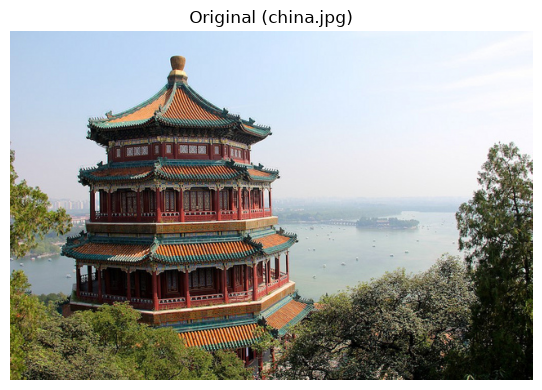

In [55]:
from sklearn.datasets import load_sample_image

china = load_sample_image("china.jpg").astype(np.float64) / 255.0       # a real 640×427 photo bundled with scikit-learn
height, width, n_channels = china.shape
print(f"image shape {china.shape} | {china.size:,} values | pixel range [{china.min():.2f}, {china.max():.2f}]")

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(china)
ax.set_title("Original (china.jpg)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Step 2 — SVD of every color channel at once

`np.linalg.svd` works on stacks of matrices, so we move the channel axis first: `(3, height, width)`.

U (3, 427, 427) | s (3, 427) | Vt (3, 427, 640)


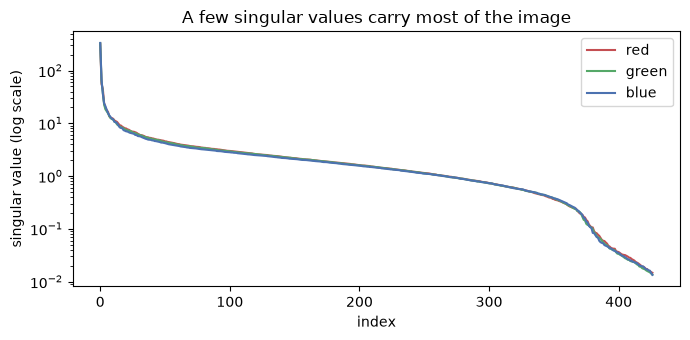

In [56]:
channels = china.transpose(2, 0, 1)                                     # (3, 427, 640)
U_img, s_img, Vt_img = np.linalg.svd(channels, full_matrices=False)
print("U", U_img.shape, "| s", s_img.shape, "| Vt", Vt_img.shape)
assert np.allclose((U_img * s_img[:, None, :]) @ Vt_img, channels)       # exact reconstruction with all ranks


def reconstruct(k):
    approx = (U_img[:, :, :k] * s_img[:, None, :k]) @ Vt_img[:, :k, :]  # (3, h, w)
    return approx.transpose(1, 2, 0)


fig, ax = plt.subplots(figsize=(7, 3.5))
for c, color in enumerate(["#C44E52", "#55A868", "#4C72B0"]):
    ax.semilogy(s_img[c], color=color, label=["red", "green", "blue"][c])
ax.set(xlabel="index", ylabel="singular value (log scale)", title="A few singular values carry most of the image")
ax.legend()
plt.tight_layout()
plt.show()

### Step 3 — Reconstruct at several ranks

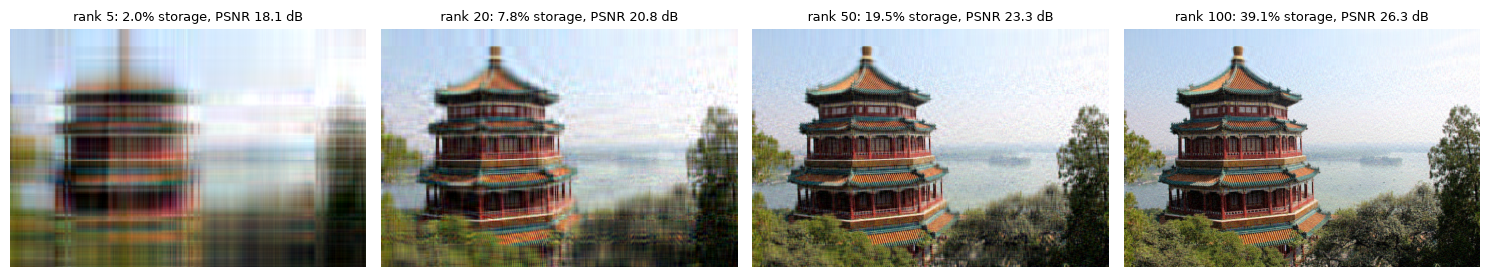

In [57]:
def storage_fraction(k):
    """Numbers stored for rank k (U columns + singular values + V rows) relative to the raw image."""
    return k * (height + width + 1) / (height * width)


def psnr(original, approx):
    mse = np.mean((original - np.clip(approx, 0, 1)) ** 2)
    return 10 * np.log10(1.0 / mse)


ranks_to_show = [5, 20, 50, 100]
fig, axes = plt.subplots(1, len(ranks_to_show), figsize=(15, 3.2))
for ax, k in zip(axes, ranks_to_show):
    ax.imshow(np.clip(reconstruct(k), 0, 1))
    ax.set_title(f"rank {k}: {storage_fraction(k):.1%} storage, PSNR {psnr(china, reconstruct(k)):.1f} dB", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Step 4 — Measure the trade-off across all ranks, and verify Eckart–Young

**Eckart–Young:** the error of the best rank-$k$ approximation (Frobenius norm) equals $\sqrt{\sum_{i>k} s_i^2}$ — the singular values we threw away. If our reconstruction matches that formula, it is provably the best possible rank-$k$ approximation.

✅ Eckart–Young verified at all 102 ranks: error = √(sum of discarded s²)


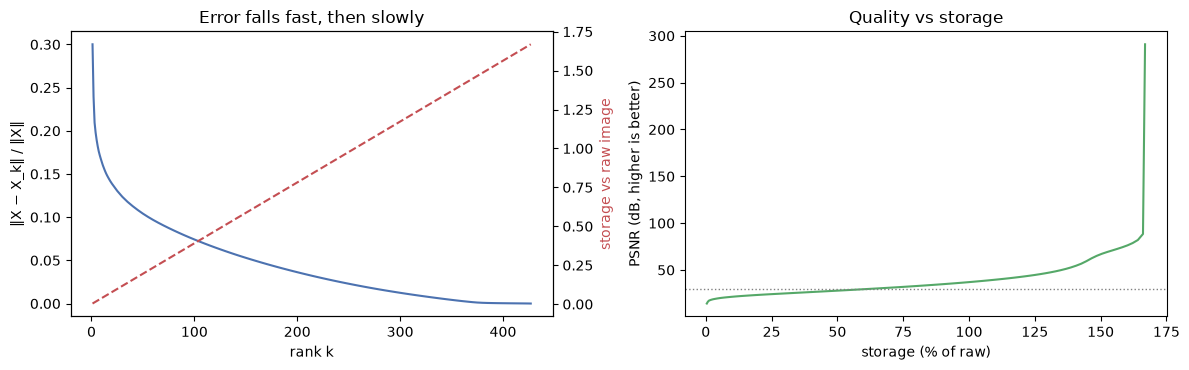

In [58]:
all_ranks = np.unique(np.concatenate([np.arange(1, 20), np.arange(20, 427, 5), [427]]))
rows = []
total_energy = np.sum(s_img ** 2)
for k in all_ranks:
    approx = reconstruct(k)
    fro_err = np.linalg.norm(china - approx)
    predicted = np.sqrt(np.sum(s_img[:, k:] ** 2))                      # discarded singular values, all channels
    assert np.isclose(fro_err, predicted, rtol=1e-6, atol=1e-8), (k, fro_err, predicted)
    rows.append((k, storage_fraction(k), fro_err / np.linalg.norm(china), psnr(china, approx),
                 np.sum(s_img[:, :k] ** 2) / total_energy))
table = np.array(rows)
print(f"✅ Eckart–Young verified at all {len(all_ranks)} ranks: error = √(sum of discarded s²)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(table[:, 0], table[:, 2], color="#4C72B0", label="relative error")
axes[0].set(xlabel="rank k", ylabel="‖X − X_k‖ / ‖X‖", title="Error falls fast, then slowly")
ax_twin = axes[0].twinx()
ax_twin.plot(table[:, 0], table[:, 1], color="#C44E52", ls="--", label="storage fraction")
ax_twin.set_ylabel("storage vs raw image", color="#C44E52")
axes[1].plot(table[:, 1] * 100, table[:, 3], color="#55A868")
axes[1].axhline(30, color="gray", ls=":", lw=1)
axes[1].set(xlabel="storage (% of raw)", ylabel="PSNR (dB, higher is better)", title="Quality vs storage")
plt.tight_layout()
plt.show()

### Step 5 — Pick the smallest rank for a quality target

A PSNR around 30 dB is a common rule of thumb for "acceptable" lossy image quality. Once rank-$k$ storage passes 100%, low-rank compression no longer saves anything.

In [59]:
TARGET_PSNR = 30.0
ok = table[table[:, 3] >= TARGET_PSNR]
k_star, store_star, err_star, psnr_star, energy_star = ok[0]
break_even = int(np.ceil(height * width / (height + width + 1)))
print(f"smallest checked rank with PSNR ≥ {TARGET_PSNR:.0f} dB: k = {int(k_star)}")
print(f"  → storage {store_star:.1%} of raw, relative error {err_star:.1%}, energy kept {energy_star:.2%}")
print(f"break-even rank (storage = 100%): k = {break_even}; full rank is {min(height, width)}")

smallest checked rank with PSNR ≥ 30 dB: k = 165
  → storage 64.5% of raw, relative error 4.8%, energy kept 99.77%
break-even rank (storage = 100%): k = 256; full rank is 427


### Step 6 — How much does the answer depend on the image?

In [60]:
flower = load_sample_image("flower.jpg").astype(np.float64) / 255.0
s_flower = np.linalg.svd(flower.transpose(2, 0, 1), compute_uv=False)


def rank_for_energy(s, target):
    energy = np.cumsum(np.sum(s ** 2, axis=0)) / np.sum(s ** 2)
    return int(np.searchsorted(energy, target) + 1)


for name, s_vals in [("china.jpg", s_img), ("flower.jpg", s_flower)]:
    print(f"{name:11s} rank for 99% energy: {rank_for_energy(s_vals, 0.99):3d} | for 99.9%: {rank_for_energy(s_vals, 0.999):3d}")
k99_c, k99_f = rank_for_energy(s_img, 0.99), rank_for_energy(s_flower, 0.99)
simpler = "china.jpg" if k99_c < k99_f else "flower.jpg"
print(f"→ {simpler} is more compressible: its energy is concentrated in fewer singular directions.")

china.jpg   rank for 99% energy:  56 | for 99.9%: 217
flower.jpg  rank for 99% energy:  29 | for 99.9%: 102
→ flower.jpg is more compressible: its energy is concentrated in fewer singular directions.


**Honest caveats:** we count stored *numbers*; real codecs also quantize and entropy-code, so JPEG beats plain SVD at the same quality. And the original is already JPEG-compressed, which makes it a bit smoother than a raw photo.

**Stretch goals**
1. Use `sklearn.utils.extmath.randomized_svd` to compute only the top 50 components and compare time and error with the full SVD (see Halko et al. in Resources).
2. Compress in a **luminance/chrominance** space (Y = 0.299R + 0.587G + 0.114B): keep more rank for Y than for the color channels, as JPEG does.
3. Split the image into 32×32 blocks and compress each block separately — does local low rank beat global low rank?
4. Connect to LoRA: for a random 768×768 "weight update", how many parameters does a rank-8 factorization `B @ A` use?

### 🗣️ How to talk about this in an interview
- "I compressed a real image with truncated SVD per color channel and measured error, PSNR and storage as a function of rank."
- "I verified the Eckart–Young theorem numerically: the reconstruction error equals the root-sum-square of the discarded singular values, so truncated SVD is the optimal rank-k approximation."
- "Storage for rank k is k(m + n + 1) versus mn, so compression only pays off well below the break-even rank."
- "The same math is PCA (SVD of centered data), collaborative filtering (low-rank user–item matrices) and LoRA (low-rank weight updates)."
- "Compressibility depends on the data: images whose singular values decay quickly need far fewer components."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Walk me through PCA. What are its assumptions and limitations?**

<details><summary>Show answer</summary>

- **30-second answer:** Center the data (standardize if features have different units) → compute the SVD of the data matrix (or eigendecomposition of the covariance) → the right singular vectors are the principal directions, sorted by variance $s_i^2/(n-1)$ → keep the top $k$ by explained variance → project. Fit on training data only.
- **Go deeper:** Assumptions: linear structure, high variance = signal, orthogonal components; sensitive to scaling and outliers. Alternatives: kernel PCA / UMAP / t-SNE for non-linear structure (t-SNE/UMAP mainly for visualization), robust PCA for outliers, randomized SVD for big data.
- **❌ Common wrong answer:** "PCA picks the most important original features." It creates new combinations of features; it doesn't select features, and it ignores the target entirely.

</details>

**Q2. What do the eigenvalues and eigenvectors of a covariance matrix tell you?**

<details><summary>Show answer</summary>

- **30-second answer:** Eigenvectors are the orthogonal directions of variation in the data; each eigenvalue is the variance along its eigenvector. Their sum is the total variance, so eigenvalue / sum is the explained variance ratio.
- **Go deeper:** A covariance matrix is symmetric positive semi-definite, so eigenvalues are real and ≥ 0 and eigenvectors orthogonal (use `eigh`). Near-zero eigenvalues signal redundant (collinear) features.
- **❌ Common wrong answer:** "Eigenvalues are the importance of each original feature."

</details>

**Q3. SVD vs eigendecomposition — what's the difference, and which do you use for PCA?**

<details><summary>Show answer</summary>

- **30-second answer:** Eigendecomposition $A = Q\Lambda Q^{-1}$ needs a square matrix (and may be complex); SVD $X = U\Sigma V^\top$ works for any $m \times n$ matrix with non-negative singular values and orthogonal $U$, $V$. For PCA, prefer SVD of the centered data: same result as eigendecomposition of $X^\top X$, but numerically more stable because it doesn't form $X^\top X$, which squares the condition number.
- **Go deeper:** $X^\top X = V\Sigma^2 V^\top$, so eigenvalues of the covariance are $s_i^2/(n-1)$. For huge matrices use truncated/randomized SVD. For symmetric PSD matrices the two decompositions coincide.
- **❌ Common wrong answer:** "They're the same thing" or "SVD only works for square matrices."

</details>

**Q4. Why do we use gradients to train models? What does the gradient point to?**

<details><summary>Show answer</summary>

- **30-second answer:** The gradient is the vector of partial derivatives of the loss; it points in the direction of steepest increase, so stepping along $-\nabla L$ decreases the loss fastest locally. It's cheap to compute for millions of parameters with backprop, unlike trying random changes.
- **Go deeper:** Step size (learning rate) must fit the curvature: too large diverges, too small crawls. Variants: SGD with mini-batches (noisy but cheap), momentum, Adam (per-parameter adaptive steps).
- **❌ Common wrong answer:** "The gradient points to the minimum." It points uphill locally, not toward the global minimum.

</details>

**Q5. How does the chain rule relate to backpropagation?**

<details><summary>Show answer</summary>

- **30-second answer:** A network is a composition of functions; the chain rule says the derivative of the composition is the product of local derivatives. Backprop runs the forward pass, stores intermediates, then multiplies local derivatives from the loss backwards, reusing shared terms so all gradients cost about one backward pass.
- **Go deeper:** That's reverse-mode automatic differentiation: efficient when there are many inputs (parameters) and one scalar output (loss). It multiplies vector–Jacobian products, never building full Jacobians. Forward-mode is better for few inputs and many outputs.
- **❌ Common wrong answer:** "Backprop computes each gradient with finite differences."

</details>

**Q6. What is convexity and why does it matter in ML?**

<details><summary>Show answer</summary>

- **30-second answer:** A function is convex if the line segment between any two points on its graph lies above the graph (bowl-shaped; Hessian PSD). Any local minimum is then global, so gradient descent with a suitable learning rate finds the best solution. Linear regression (MSE), logistic regression (log-loss) and SVMs have convex losses.
- **Go deeper:** Neural networks are non-convex (many minima and saddle points), but in practice SGD finds good solutions; initialization, normalization and learning-rate schedules matter. Adding L2 regularization makes a convex loss strictly convex (unique minimum).
- **❌ Common wrong answer:** "Convex means the function has no minimum" (confusing convex with concave), or "neural network losses are convex."

</details>

**Q7. Why use cross-entropy instead of MSE for classification?**

<details><summary>Show answer</summary>

- **30-second answer:** Cross-entropy is the negative log-likelihood of the labels under the model's predicted probabilities, so minimizing it is maximum likelihood. With sigmoid/softmax outputs, its gradient w.r.t. logits is `p − y` — large when confidently wrong — while MSE's gradient is multiplied by σ′(z), which vanishes when the model is saturated and wrong. Cross-entropy with logistic regression is also convex; MSE with a sigmoid is not.
- **Go deeper:** Implement from logits (log-softmax / `BCEWithLogitsLoss`) for numerical stability. Cross-entropy strongly penalizes confident mistakes, which also makes it sensitive to label noise (label smoothing helps).
- **❌ Common wrong answer:** "MSE can't be used for classification at all." It can; it just trains worse and isn't a proper likelihood for categorical outputs.

</details>

**Q8. What is KL divergence? Is it a distance?**

<details><summary>Show answer</summary>

- **30-second answer:** $D_{KL}(p\Vert q) = \sum p \log(p/q)$ = extra expected surprise from using $q$ when the truth is $p$; it equals cross-entropy minus entropy, is ≥ 0, and is 0 only when $p = q$. It is **not** a distance: it's asymmetric and fails the triangle inequality.
- **Go deeper:** Forward KL (p‖q) is mass-covering and is what maximum likelihood minimizes; reverse KL (q‖p) is mode-seeking and appears in variational inference. KL shows up in VAEs, knowledge distillation and the KL penalty that keeps an RLHF policy close to a reference model. Symmetric alternatives: Jensen–Shannon divergence.
- **❌ Common wrong answer:** "KL(p‖q) = KL(q‖p)."

</details>

### 💻 Coding

**Q9. Implement PCA in NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:** `mu = X.mean(0); U, s, Vt = np.linalg.svd(X - mu, full_matrices=False); components = Vt[:k]; Z = (X - mu) @ components.T; ratio = s[:k]**2 / np.sum(s**2)`.
- **Go deeper:** Mention sign ambiguity (fix with a convention like sklearn's `svd_flip`), store `mu` for transforming new data, `inverse_transform = Z @ components + mu`, and use randomized SVD when only a few components of a large matrix are needed.
- **❌ Common wrong answer:** Forgetting to center, or taking columns of `Vt` instead of rows.

</details>

**Q10. Implement a numerically stable softmax cross-entropy from logits, and give its gradient.**

<details><summary>Show answer</summary>

- **30-second answer:** `z = logits - logits.max(1, keepdims=True); log_p = z - np.log(np.exp(z).sum(1, keepdims=True)); loss = -log_p[np.arange(n), y].mean()`. Gradient w.r.t. logits: `(softmax(logits) - one_hot(y)) / n`.
- **Go deeper:** The shift by the max (log-sum-exp trick) prevents overflow; working in log space avoids `log(0)`. Verify the gradient with a numerical gradient check.
- **❌ Common wrong answer:** `np.log(softmax(logits))` — underflows to `log(0) = -inf` for very negative logits.

</details>

### 🐛 Debugging Scenarios

**Q11. Your gradient check fails for your custom layer. What could be wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** A real bug in the backward pass (missing activation derivative, wrong axis in a sum, missing `1/n`, broadcasting a bias gradient incorrectly) — or a problem with the check itself: float32 instead of float64, a step `h` that is too small/large, randomness (dropout) or non-differentiable points like ReLU at 0.
- **Go deeper:** Check one parameter tensor at a time, use relative error, test on a tiny batch, and compare per-element to find the wrong entries. Remember to restore each parameter after nudging it.
- **❌ Common wrong answer:** "Numerical gradients are always approximate, so a mismatch is fine." A relative error around 1e-2 almost always means a bug.

</details>

**Q12. Two teammates' PCA results have opposite signs on some components. Who is wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Neither — if $v$ is a principal direction, so is $-v$. Distances, explained variance and reconstructions are identical. Compare components sign-agnostically (|cosine| ≈ 1) or apply a sign convention.
- **Go deeper:** Signs can even change between library versions or solvers; scikit-learn applies `svd_flip` for determinism. If you interpret component weights, fix a convention; if you feed components into another model trained earlier, persist the fitted PCA object instead of refitting.
- **❌ Common wrong answer:** "One of them has a bug in the SVD."

</details>

**Q13. Your loss becomes NaN a few hundred steps into training. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Learning rate too high (loss grows then explodes), exploding gradients (log the gradient norm; clip), `log(0)` or division by zero in a hand-written loss (use from-logits losses, add epsilons), unscaled inputs, or bad data (NaN/inf in a batch).
- **Go deeper:** In mixed precision, float16 overflow — use bfloat16 or loss scaling. Add `assert np.isfinite(loss)` checks and find the first bad batch.
- **❌ Common wrong answer:** "Just restart with a different random seed."

</details>

### 🏗️ Design

**Q14. You have 50 million 768-dimensional text embeddings and search is too slow and memory-hungry. Would you use PCA? What are the trade-offs?**

<details><summary>Show answer</summary>

- **30-second answer:** PCA to ~128–256 dims can cut memory and distance cost several-fold; fit it on a representative sample, check retrieval recall@k on a labeled evaluation set before and after, and re-normalize vectors if you use cosine similarity. Often combine with (or replace by) quantization and an approximate-nearest-neighbour index (e.g. IVF-PQ or HNSW in FAISS).
- **Go deeper:** Explained variance isn't the metric that matters — retrieval quality is. Product quantization compresses much more aggressively; some embedding models are trained to be truncatable (Matryoshka embeddings). The PCA model must be versioned with the index, and new data drift may require refitting.
- **❌ Common wrong answer:** "Keep enough components for 95% variance and you're done" without measuring search recall.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** What is the shape of `np.ones((3, 4)) @ np.ones((4, 2))`?
<details><summary>Answer</summary>

`(3, 2)` — inner dimensions (4 and 4) match and disappear.
</details>

**2.** `np.linalg.matrix_rank(np.array([[1, 2], [2, 4]]))`
<details><summary>Answer</summary>

`1` — the second column is 2× the first, so there is only one independent direction (and the determinant is 0).
</details>

**3.** Gradient descent on $f(x) = x^2$ with learning rate 1.5, starting at $x = 1$. What happens?
<details><summary>Answer</summary>

It **diverges**: $x \leftarrow x - 1.5 \cdot 2x = -2x$, giving 1, −2, 4, −8, … Any learning rate above 1 (= 2 / curvature 2) diverges on this function.
</details>

**4.** The entropy of a fair coin, in bits?
<details><summary>Answer</summary>

`1.0` — the maximum for two outcomes.
</details>

**5.** For p = [0.5, 0.5] and q = [0.9, 0.1], is KL(p‖q) equal to KL(q‖p)?
<details><summary>Answer</summary>

**No** — KL(p‖q) ≈ 0.511 nats but KL(q‖p) ≈ 0.368 nats. KL divergence is asymmetric.
</details>

## 📚 Resources

### 📖 Official Docs
- [Linear algebra — NumPy Manual](https://numpy.org/doc/stable/reference/routines.linalg.html) — `solve`, `lstsq`, `svd`, `eigh`, `norm`, `cond`
- [Decomposing signals in components — scikit-learn](https://scikit-learn.org/stable/modules/decomposition.html) — PCA, truncated/randomized SVD, and friends
- [Calculus — SymPy documentation](https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html) — symbolic derivatives, limits, series
- [log_loss — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html) · [entropy — SciPy Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html) — cross-entropy, entropy and KL in libraries
- [load_sample_image — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_sample_image.html) — the photos used in the mini project

### 🎥 Videos
- [3Blue1Brown — Essence of linear algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) (16 short videos) — the best visual intuition for vectors, matrices as transformations, determinants and eigenvectors; watch alongside sections 1–7
- [StatQuest with Josh Starmer — StatQuest: Principal Component Analysis (PCA), Step-by-Step](https://www.youtube.com/watch?v=FgakZw6K1QQ) (22 m) — a slow, friendly walkthrough of every PCA step and the vocabulary interviewers use
- [3Blue1Brown — Backpropagation calculus | Deep Learning Chapter 4](https://www.youtube.com/watch?v=tIeHLnjs5U8) (10 m) — the chain rule inside a neural network, animated; pairs with section 10
- [Artem Kirsanov — The Key Equation Behind Probability](https://www.youtube.com/watch?v=KHVR587oW8I) (26 m) — builds surprise → entropy → cross-entropy → KL divergence from scratch; pairs with section 14

### 📄 Papers
- [Shlens (2014) — A Tutorial on Principal Component Analysis](https://arxiv.org/abs/1404.1100) — PCA derived gently, with its assumptions spelled out
- [Halko, Martinsson & Tropp (2011) — Finding structure with randomness: Probabilistic algorithms for constructing approximate matrix decompositions](https://arxiv.org/abs/0909.4061) — the randomized SVD behind fast PCA on big data
- [Parr & Howard (2018) — The Matrix Calculus You Need For Deep Learning](https://arxiv.org/abs/1802.01528) — Jacobians and the vector chain rule, written for practitioners
- [Hu et al. (2021) — LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685) — low-rank matrices applied to LLM fine-tuning
- [Shannon (1948) — A Mathematical Theory of Communication](https://people.math.harvard.edu/~ctm/home/text/others/shannon/entropy/entropy.pdf) — where entropy comes from

### 📘 Books & Courses
- [Mathematics for Machine Learning (free book)](https://mml-book.github.io/) — Deisenroth, Faisal & Ong: linear algebra, calculus, probability and PCA for ML
- [Deep Learning (free online book)](https://www.deeplearningbook.org/) — Goodfellow, Bengio & Courville; chapters 2–4 are a compact math refresher
- [CS231n Deep Learning for Computer Vision — backpropagation notes](https://cs231n.github.io/optimization-2/) — computational graphs and gradient flow; [gradient checking tips](https://cs231n.github.io/neural-networks-3/)
- [Andrej Karpathy — The spelled-out intro to neural networks and backpropagation: building micrograd](https://www.youtube.com/watch?v=VMj-3S1tku0) (2 h 25 m) — build autograd from the chain rule; a perfect next step after section 10

### 🏋️ Practice
- [Deep-ML | Practice Machine Learning](https://www.deep-ml.com/) — coding problems on linear algebra, PCA, gradients and losses in NumPy
- [100 NumPy exercises](https://github.com/rougier/numpy-100) — sharpen the array skills all of this math relies on

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Norm | vector length | `np.linalg.norm(v)` (L2), `ord=1` (L1) |
| Dot product | alignment × lengths | `a @ b = ‖a‖‖b‖cos θ` |
| Cosine similarity | direction-only similarity | `a @ b / (‖a‖ ‖b‖)` |
| Projection | shadow of b on a | `(a @ b) / (a @ a) * a` |
| Matrix | linear transformation | columns = images of basis vectors; `det` = area scale |
| Matmul shapes | compose transformations | `(n, k) @ (k, m) → (n, m)` |
| Rank | number of independent directions | `np.linalg.matrix_rank`; rank-deficient ⇒ no unique solution |
| Solve | find x in Ax = b | `np.linalg.solve`, `lstsq` — not `inv`; watch `np.linalg.cond` |
| Eigen | directions only stretched | `Av = λv`; `np.linalg.eigh` for symmetric |
| SVD | rotate–stretch–rotate, any matrix | `U, s, Vt = np.linalg.svd(X, full_matrices=False)`; truncation = best rank-k |
| PCA | variance-ordered axes | center → SVD → `Vt[:k]`; variance `s²/(n−1)`; fit on train only |
| Derivative | slope | central difference `(f(x+h) − f(x−h)) / 2h`, `sp.diff` |
| Chain rule / backprop | slope of a composition | `dL/dx = dL/dy · dy/dx`, reuse upstream gradients |
| Gradient | steepest ascent | `∇f`; step `p ← p − η ∇f(p)` |
| Gradient check | verify backprop | relative error `‖g₁−g₂‖/(‖g₁‖+‖g₂‖)` < 1e-6 |
| Hessian / convexity | curvature | PSD Hessian ⇒ convex ⇒ local min = global min |
| Entropy / cross-entropy / KL | uncertainty and mismatch | `−Σp log p`, `−Σp log q`, `Σp log(p/q)` (asymmetric) |
| Classification loss | NLL of true class | cross-entropy from logits; gradient `p − y` |

## ➡️ What's Next

**[05 · Statistics and Probability](05_Statistics_and_Probability.ipynb)** — you now have the linear algebra, calculus and information theory models are built on; next you'll learn distributions, sampling, confidence intervals and hypothesis tests, so you can tell whether a model improvement or an A/B-test result is real or just noise.